# exploring symbiont communities in individual colonies overtime

## questions:
- are the symbiont communities changing during times of bleaching?
how about during disease outbreak?

In [50]:
require(data.table)
require(tidyverse)
require(phyloseq)
require(ggplot2)
require(RColorBrewer)
require(metacoder)
require(vegan)
require(DESeq2)

### ps cleanup
- remove Diseased_margin
- remove taxa that never show up
- normalize

In [51]:
ps<-readRDS(file = "/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/BEL_ITS2_outputs/ps_all_ITS2.rds")
#removing any taxa that don't show up in any samples to speed up the process
ps

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 257 taxa and 479 samples ]
sample_data() Sample Data:       [ 479 samples by 26 sample variables ]
tax_table()   Taxonomy Table:    [ 257 taxa by 8 taxonomic ranks ]

In [52]:
## remove samples with zero reads


In [53]:
## removing diseased_margin from ps_col

#new dataframes for each species 
ps_nomargin <- subset_samples(ps, Health_status != "Diseased_Margin")

#how many samples did I remove?
ps_nomargin

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 257 taxa and 450 samples ]
sample_data() Sample Data:       [ 450 samples by 26 sample variables ]
tax_table()   Taxonomy Table:    [ 257 taxa by 8 taxonomic ranks ]

In [54]:
ps_prune <- prune_taxa(taxa_sums(ps_nomargin) > 0, ps_nomargin)
ps_prune

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 251 taxa and 450 samples ]
sample_data() Sample Data:       [ 450 samples by 26 sample variables ]
tax_table()   Taxonomy Table:    [ 251 taxa by 8 taxonomic ranks ]

### clean up sample data
- convert ps object to df using vegan
- isolate only colonies that were sampled multiple times
- order the colonies by if they ever had diseased/ were ever bleached


In [55]:
pssd2veg <- function(ps_prune) {
  sd_nomit <- sample_data(ps_prune)
  return(as(sd_nomit,"data.frame"))
}
#using phyloseq nmds plot no chloroplast
sample_nomit <- pssd2veg(ps_prune)

sample_nomit <- as.data.frame(sample_data(ps_prune))
#save sammple names as a column so tidy doesn't get rid of it during filtering
sample_nomit$SampleID <- rownames(sample_nomit)

In [56]:
# Return names which have more than one row of data
# Now filter
colonies <- sample_nomit %>%
  group_by(colony) %>%
  filter(n() != 1) %>%
  ungroup()

#difference bw og and repeated colonies df
nrow(sample_nomit)
nrow(colonies)

[1] 450

[1] 433

In [57]:
#how many colonies are represented?
length(unique(colonies$colony))
head(colonies)

[1] 64

V1,Date_Extracted,Raw_ng_ul,Date_Enriched,Microbe_Location,Month_year,colony,CollectionDate,Species,Health_status,⋯,Transect,sample_uid,data_set_uid,host_family,host_genus,host_species,collection_date,collection_depth,DateFormatted,SampleID
<int>,<chr>,<chr>,<chr>,<chr>,<fct>,<chr>,<fct>,<chr>,<chr>,⋯,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<date>,<chr>
1,2_17_2025,44.6,,,Jan 2024,1_3,1/10/24,SSID,Healthy,⋯,CBC30N,272206,1503,Rhizangiidae,Siderastrea,sidera,20240110,8,2024-01-10,012024_BEL_CBC_T1_557_SSID
2,2_17_2025,14.8,,,Jan 2024,1_24,1/10/24,MCAV,Healthy,⋯,CBC30N,272302,1503,Montastraeidae,Montastrea,cavernosa,20240110,8,2024-01-10,012024_BEL_CBC_T1_559_MCAV
3,2_17_2025,18,,,Jan 2024,1_25,1/10/24,OANN,Healthy,⋯,CBC30N,272398,1503,Merulinidae,Orbicella,annularis,20240110,8,2024-01-10,012024_BEL_CBC_T1_561_OANN
4,2_17_2025,35.8,,,Jan 2024,1_12,1/10/24,PSTR,Healthy,⋯,CBC30N,272207,1503,Faviidae,Pseudodiploria,strigosa,20240110,8,2024-01-10,012024_BEL_CBC_T1_563_PSTR
5,2_17_2025,7.72,,,Jan 2024,1_21,1/10/24,PAST,Bleached_Tissue,⋯,CBC30N,272494,1503,Poritidae,Porites,asteroides,20240110,8,2024-01-10,012024_BEL_CBC_T1_565_PAST
6,2_17_2025,71.6,,,Jan 2024,2_76,1/12/24,OFAV,Healthy,⋯,SR30N,272495,1503,Merulinidae,Orbicella,faveolata,20240112,8,2024-01-12,012024_BEL_CBC_T2_585_OFAV


#### clean colonies df up

In [58]:
colonies <- as.data.frame(colonies)
class(colonies)

Warning message in class(x) <- tibble_class:
“Setting class(x) to multiple strings ("tbl_df", "tbl", ...); result will no longer be an S4 object”


[1] "data.frame"

In [59]:
# Restore rownames
rownames(colonies) <- colonies$SampleID
#check
head(rownames(colonies))
nrow(sample_data(ps_prune))

[1] "012024_BEL_CBC_T1_557_SSID" "012024_BEL_CBC_T1_559_MCAV"
[3] "012024_BEL_CBC_T1_561_OANN" "012024_BEL_CBC_T1_563_PSTR"
[5] "012024_BEL_CBC_T1_565_PAST" "012024_BEL_CBC_T2_585_OFAV"

[1] 450

In [60]:
head(colonies)

,V1,Date_Extracted,Raw_ng_ul,Date_Enriched,Microbe_Location,Month_year,colony,CollectionDate,Species,Health_status,⋯,Transect,sample_uid,data_set_uid,host_family,host_genus,host_species,collection_date,collection_depth,DateFormatted,SampleID
,<int>,<chr>,<chr>,<chr>,<chr>,<fct>,<chr>,<fct>,<chr>,<chr>,⋯,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<date>,<chr>
012024_BEL_CBC_T1_557_SSID,1,2_17_2025,44.6,,,Jan 2024,1_3,1/10/24,SSID,Healthy,⋯,CBC30N,272206,1503,Rhizangiidae,Siderastrea,sidera,20240110,8,2024-01-10,012024_BEL_CBC_T1_557_SSID
012024_BEL_CBC_T1_559_MCAV,2,2_17_2025,14.8,,,Jan 2024,1_24,1/10/24,MCAV,Healthy,⋯,CBC30N,272302,1503,Montastraeidae,Montastrea,cavernosa,20240110,8,2024-01-10,012024_BEL_CBC_T1_559_MCAV
012024_BEL_CBC_T1_561_OANN,3,2_17_2025,18,,,Jan 2024,1_25,1/10/24,OANN,Healthy,⋯,CBC30N,272398,1503,Merulinidae,Orbicella,annularis,20240110,8,2024-01-10,012024_BEL_CBC_T1_561_OANN
012024_BEL_CBC_T1_563_PSTR,4,2_17_2025,35.8,,,Jan 2024,1_12,1/10/24,PSTR,Healthy,⋯,CBC30N,272207,1503,Faviidae,Pseudodiploria,strigosa,20240110,8,2024-01-10,012024_BEL_CBC_T1_563_PSTR
012024_BEL_CBC_T1_565_PAST,5,2_17_2025,7.72,,,Jan 2024,1_21,1/10/24,PAST,Bleached_Tissue,⋯,CBC30N,272494,1503,Poritidae,Porites,asteroides,20240110,8,2024-01-10,012024_BEL_CBC_T1_565_PAST
012024_BEL_CBC_T2_585_OFAV,6,2_17_2025,71.6,,,Jan 2024,2_76,1/12/24,OFAV,Healthy,⋯,SR30N,272495,1503,Merulinidae,Orbicella,faveolata,20240112,8,2024-01-12,012024_BEL_CBC_T2_585_OFAV


#### order by ever diseased/bleached and colonies that were only ever paled (never experienced full bleaching)

In [61]:
## how many colonies only ever experienced paling?
paling_only_count <- colonies %>%
  group_by(colony) %>%
  summarize(
    ever_paled = any(Condition == "CLP"),
    ever_fully_bleached = any(Condition %in% c("CLP,CLB", "CLB"))
  ) %>%
  # Filter for colonies that paled, but NEVER fully bleached
  filter(ever_paled == TRUE & ever_fully_bleached == FALSE) %>% 
  nrow()

print(paling_only_count)

[1] 14


In [62]:
#group by colony
colony_history <- colonies %>%
  group_by(colony) %>%
  summarize(
    # ever_diseased means that the colony was diagnosed with SCTLD
    ever_diseased = any(Condition == "Diseased"),
    
    # ever_bleached strictly means it hit full bleaching (CLB or CLP,CLB)
    ever_bleached = any(grepl("CLB", Condition)),
    
    # only_paled means it had CLP, but NEVER progressed to having CLB
    only_paled    = any(grepl("CLP", Condition)) & !ever_bleached
  )

# The rest of your labeling and arranging code works exactly the same:
colony_order_df <- colony_history %>%
  arrange(desc(ever_diseased), desc(ever_bleached), desc(only_paled), colony) %>%
  mutate(colony_label = case_when(
    ever_diseased == TRUE ~ paste(colony, "(Diseased)"),
    ever_bleached == TRUE ~ paste(colony, "(Bleached)"),
    only_paled    == TRUE ~ paste(colony, "(Paled Only)"),
    TRUE                  ~ as.character(colony)
  ))

In [63]:
# 3. Extract your vectors
ordered_colonies <- colony_order_df$colony
ordered_labels   <- colony_order_df$colony_label

### bring cleaned sample data into a new ps object
- ps_col

In [64]:
keep_samples <- rownames(colonies)
length(keep_samples)
#how many of the values in keep_samples exist in ps_norm
sum(keep_samples %in% sample_names(ps_prune))  # Should be 421

[1] 433

[1] 433

In [65]:
head(sample_names(ps_prune))
head(keep_samples)

[1] "012024_BEL_CBC_T1_557_SSID" "012024_BEL_CBC_T1_559_MCAV"
[3] "012024_BEL_CBC_T1_561_OANN" "012024_BEL_CBC_T1_563_PSTR"
[5] "012024_BEL_CBC_T1_565_PAST" "012024_BEL_CBC_T2_585_OFAV"

[1] "012024_BEL_CBC_T1_557_SSID" "012024_BEL_CBC_T1_559_MCAV"
[3] "012024_BEL_CBC_T1_561_OANN" "012024_BEL_CBC_T1_563_PSTR"
[5] "012024_BEL_CBC_T1_565_PAST" "012024_BEL_CBC_T2_585_OFAV"

In [66]:
# Prune to keep only those samples
ps_col <- prune_samples(sample_names(ps_prune) %in% keep_samples, ps_prune)

In [67]:
## check up on ps_col
class(ps_col)
all(rownames(colonies) %in% sample_names(ps_col))
ps_col

[1] "phyloseq"
attr(,"package")
[1] "phyloseq"

[1] TRUE

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 251 taxa and 433 samples ]
sample_data() Sample Data:       [ 433 samples by 26 sample variables ]
tax_table()   Taxonomy Table:    [ 251 taxa by 8 taxonomic ranks ]

In [68]:
colnames(tax_table(ps_col))

[1] "Clade"                                            
[2] "Majority.ITS2.sequence"                           
[3] "Associated.species"                               
[4] "ITS2.profile.abundance.local"                     
[5] "ITS2.profile.abundance.DB"                        
[6] "ITS2.type.profile"                                
[7] "Sequence.accession...SymPortal.UID"               
[8] "Average.defining.sequence.proportions.and..stdev."

In [69]:
#checking on ps_col
nrow(sample_data(ps_col))
head(sample_data(ps_col))

[1] 433

,V1,Date_Extracted,Raw_ng_ul,Date_Enriched,Microbe_Location,Month_year,colony,CollectionDate,Species,Health_status,⋯,Seq_run,Transect,sample_uid,data_set_uid,host_family,host_genus,host_species,collection_date,collection_depth,DateFormatted
,<int>,<chr>,<chr>,<chr>,<chr>,<fct>,<chr>,<fct>,<chr>,<chr>,⋯,<int>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<date>
012024_BEL_CBC_T1_557_SSID,1,2_17_2025,44.6,,,Jan 2024,1_3,1/10/24,SSID,Healthy,⋯,1,CBC30N,272206,1503,Rhizangiidae,Siderastrea,sidera,20240110,8,2024-01-10
012024_BEL_CBC_T1_559_MCAV,2,2_17_2025,14.8,,,Jan 2024,1_24,1/10/24,MCAV,Healthy,⋯,2,CBC30N,272302,1503,Montastraeidae,Montastrea,cavernosa,20240110,8,2024-01-10
012024_BEL_CBC_T1_561_OANN,3,2_17_2025,18,,,Jan 2024,1_25,1/10/24,OANN,Healthy,⋯,3,CBC30N,272398,1503,Merulinidae,Orbicella,annularis,20240110,8,2024-01-10
012024_BEL_CBC_T1_563_PSTR,4,2_17_2025,35.8,,,Jan 2024,1_12,1/10/24,PSTR,Healthy,⋯,1,CBC30N,272207,1503,Faviidae,Pseudodiploria,strigosa,20240110,8,2024-01-10
012024_BEL_CBC_T1_565_PAST,5,2_17_2025,7.72,,,Jan 2024,1_21,1/10/24,PAST,Bleached_Tissue,⋯,4,CBC30N,272494,1503,Poritidae,Porites,asteroides,20240110,8,2024-01-10
012024_BEL_CBC_T2_585_OFAV,6,2_17_2025,71.6,,,Jan 2024,2_76,1/12/24,OFAV,Healthy,⋯,4,SR30N,272495,1503,Merulinidae,Orbicella,faveolata,20240112,8,2024-01-12


### clean up ps_col
- dates in chronological order
- new column named colony_labeled to use for diseased/bleached facets

In [70]:
unique(colonies$Month_year)

[1] Jan 2024 Feb 2024 Apr 2024 May 2022 Jun 2019 Jun 2024 Aug 2024 Sep 2023
 [9] Oct 2019 Nov 2023 Dec 2022 Dec 2023 <NA>    
12 Levels: Jan 2024 Feb 2024 Apr 2024 May 2022 Jun 2019 Jun 2024 ... Dec 2023

In [71]:
# 2. reorder MonthYear as a factor in chronological order
sample_data(ps_col)$Month_year <- factor(sample_data(ps_col)$Month_year,levels = c("Jun 2019", "Oct 2019", "May 2022", "Dec 2022", "Sep 2023","Nov 2023","Dec 2023","Jan 2024","Feb 2024","Apr 2024","Jun 2024","Aug 2024"))

In [72]:
# adding diseased vs bleached labels to facets

#create new col colony_labeled 

current_colonies <- sample_data(ps_col)$colony

# Create a column in sample_data(ps_col) where the disease, CLB, CLp VALUES are the labels, but the LEVELS dictate the order
sample_data(ps_col)$colony_labeled <- factor(
  colony_order_df$colony_label[match(current_colonies, colony_order_df$colony)],
  levels = ordered_labels
)

## how are the symbiont communities changing in individual corals overtime through stressors?

### taxa
#### clades

In [73]:
# confirm that singleton is removed
table(tax_table(ps_col)[, "Clade"])


 A  B  C  D  G 
78 93 55 21  4 

In [74]:
    # how many unique family taxa are there? 
length(unique(tax_table(ps_col)[, "Clade"])) # should be 5

rank_names(ps_col)

#check if clade is a factor
class(tax_table(ps_col)[, "Clade"])

[1] 5

[1] "Clade"                                            
[2] "Majority.ITS2.sequence"                           
[3] "Associated.species"                               
[4] "ITS2.profile.abundance.local"                     
[5] "ITS2.profile.abundance.DB"                        
[6] "ITS2.type.profile"                                
[7] "Sequence.accession...SymPortal.UID"               
[8] "Average.defining.sequence.proportions.and..stdev."

[1] "taxonomyTable"
attr(,"package")
[1] "phyloseq"

### plotting

In [75]:
options(repr.plot.width=20, repr.plot.height=15)

#### assigning clade colors 

In [84]:
clade <- unique(tax_table(ps_col)[, "Clade"])

base_palette<-c("#6c086d",
"#1d61ae",
"#319a2d",
"#c91010",
"#f2d042")

cladecolors <- sample(base_palette, length(clade))

In [89]:
base_palette
cladecolors

[1] "#6c086d" "#1d61ae" "#319a2d" "#c91010" "#f2d042"

[1] "#319a2d" "#f2d042" "#1d61ae" "#6c086d" "#c91010"

In [91]:
# names(coral_colors) <- unique(metadata$Species)
names(cladecolors) <- unique(tax_table(ps_col)[, "Clade"])
# clade_colors
base_palette
cladecolors

A         B         C         D         G 
"#6c086d" "#1d61ae" "#319a2d" "#c91010" "#f2d042"

A         B         C         D         G 
"#319a2d" "#f2d042" "#1d61ae" "#6c086d" "#c91010"

## overall clade plot

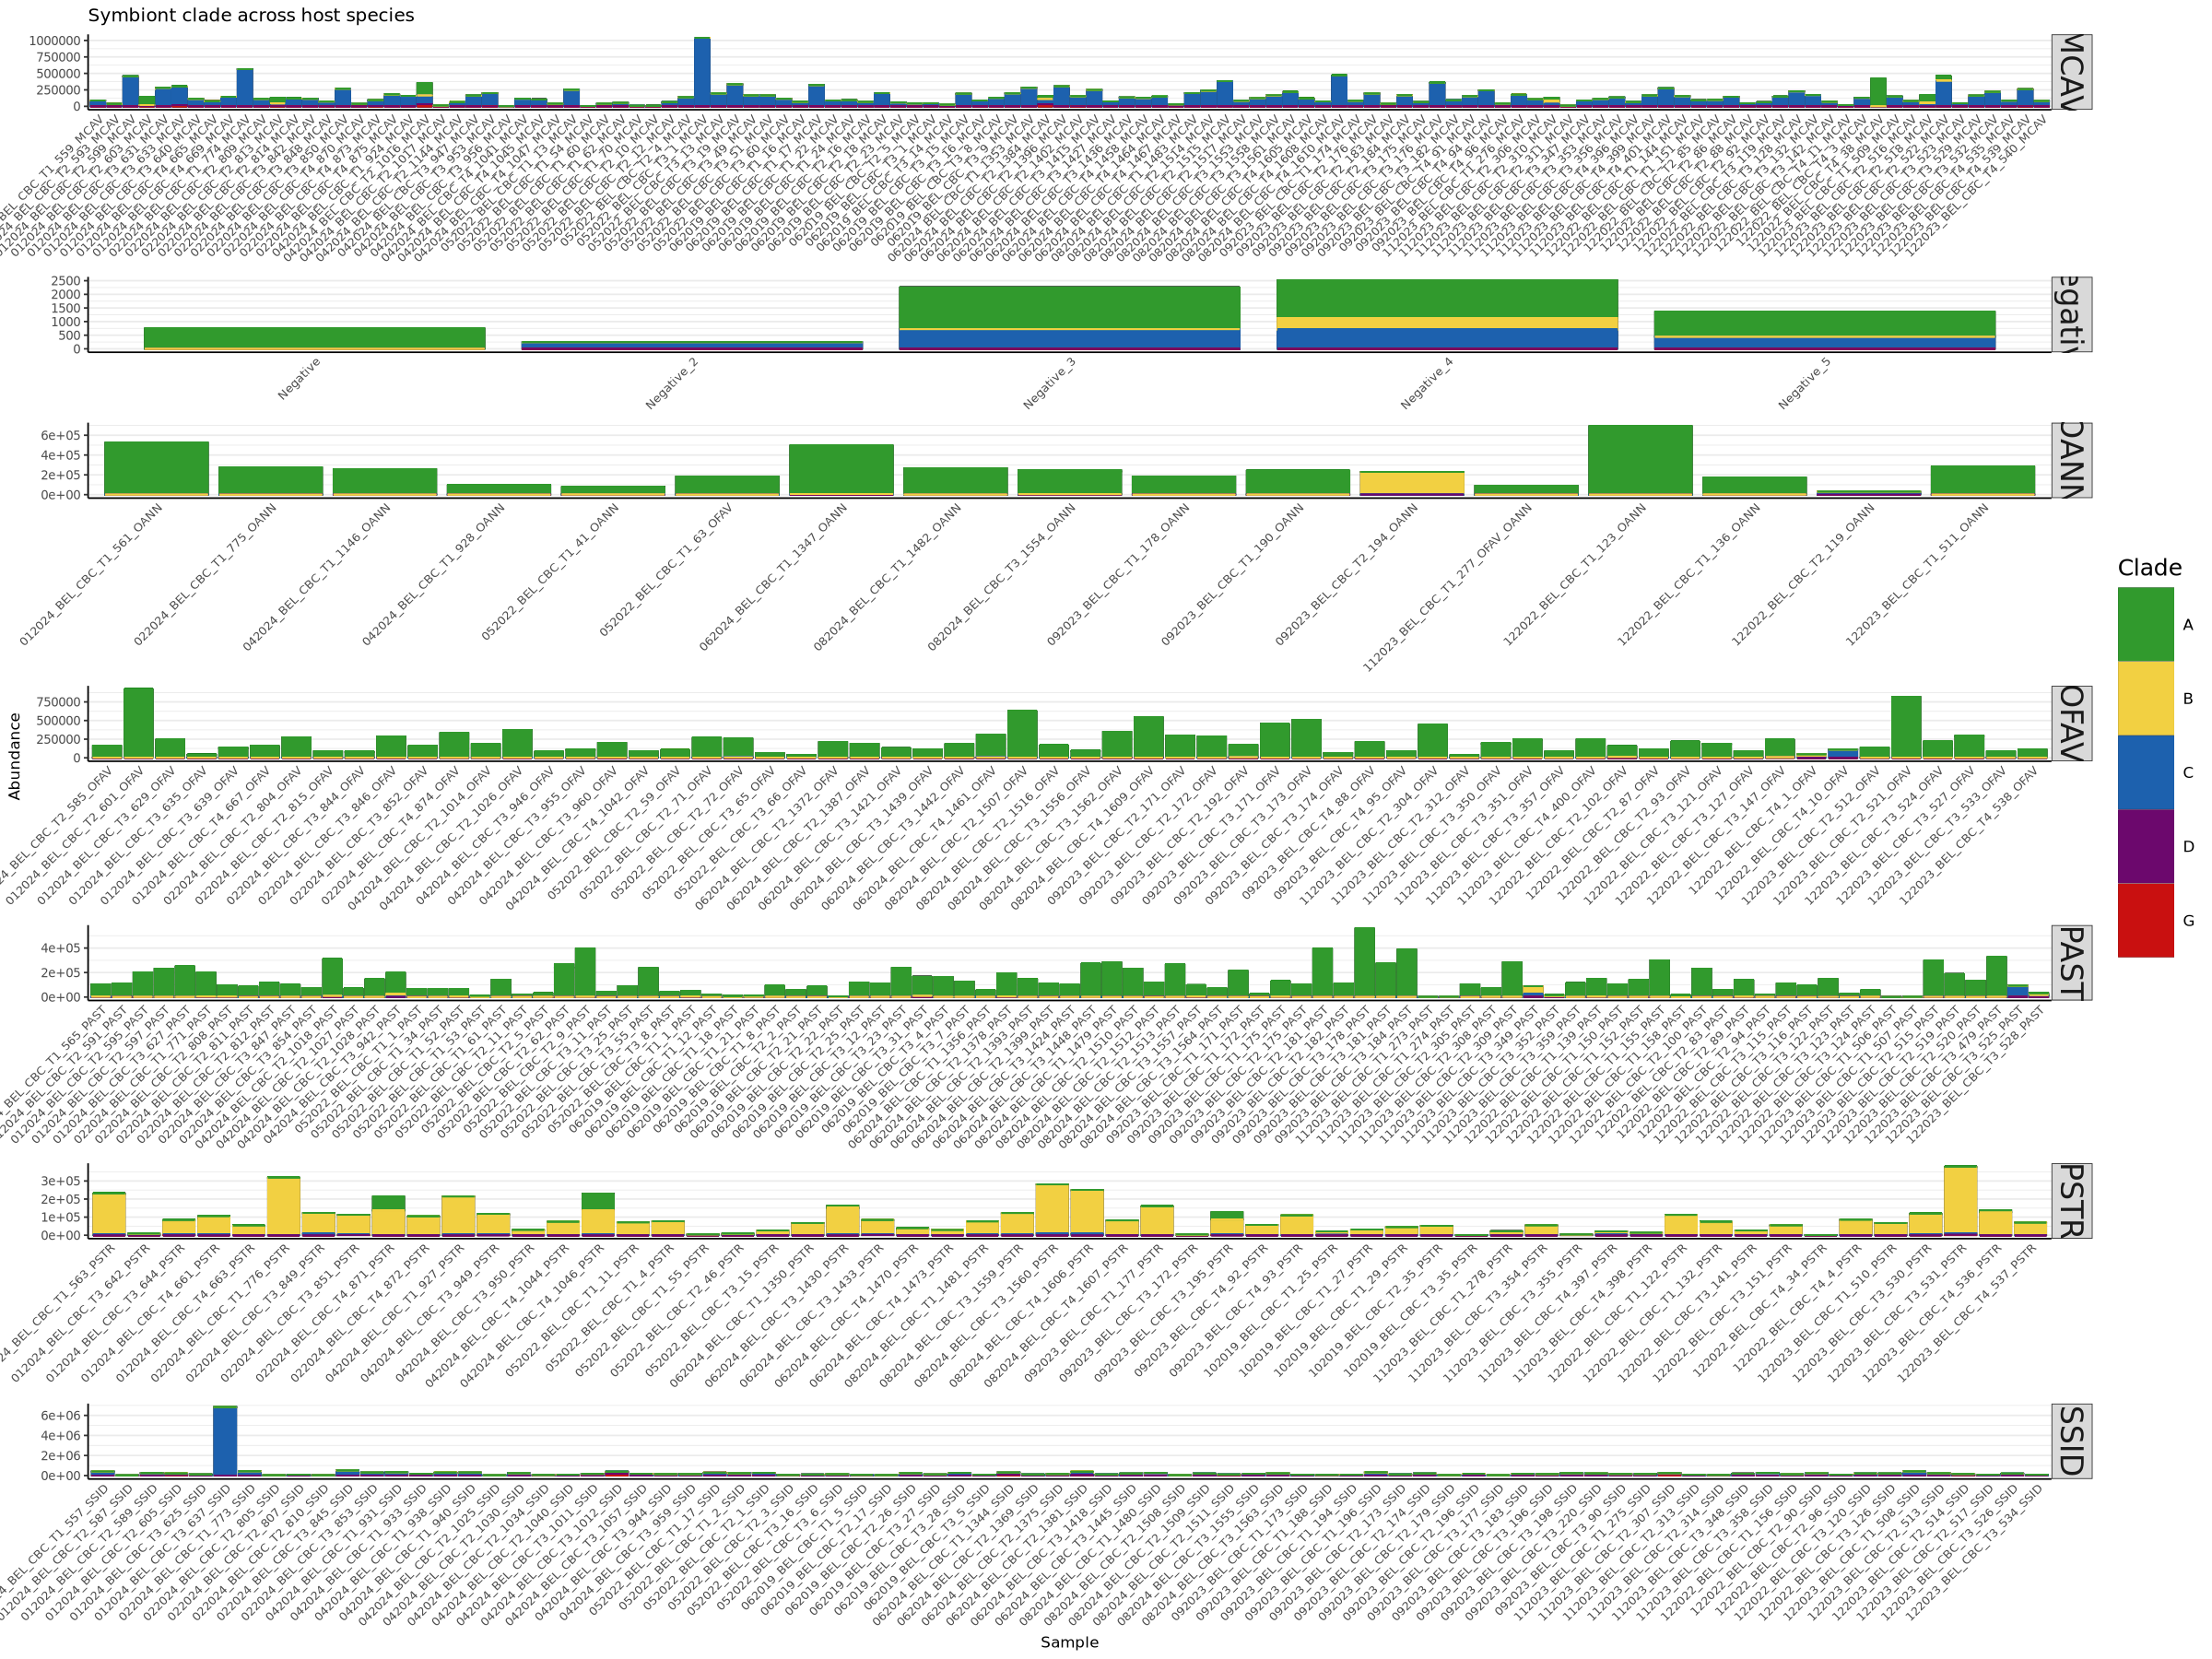

In [92]:
clade_plot <- plot_bar(ps_col, fill = "Clade") +
facet_wrap(Species ~., strip.position = "right",  ncol = 1, scales = "free") + # Set desired font size
  geom_bar(aes(color = Clade, fill = Clade), 
           stat = "identity", position = "stack") +
  labs(title = "Symbiont clade across host species",
       x = "Sample",
       y = "Abundance",
       color = "Clade") +
  scale_fill_manual(values = cladecolors, drop = TRUE) +
  scale_color_manual(values = cladecolors, drop = TRUE) +
  theme_bw() +
  theme(strip.text = element_text(size = 20), #facet text size
    legend.position = "right",
    legend.title = element_text(size = 15),
  legend.text = element_text(size = 10),
legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.7, "cm"),   # make them taller
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size =10)
  ) + 
guides(color = guide_legend(override.aes = list(size = 6))) 
clade_plot

## colonies over_time

## overall its2 profile plot

#### its2 profile prep

In [93]:
    # how many unique family taxa are there?
length(unique(tax_table(ps_col)[, "ITS2.type.profile"]))

[1] 251

In [94]:
    # how many unique family taxa are there?
length(unique(tax_table(ps_col)[, "Majority.ITS2.sequence"]))

[1] 59

In [95]:
# 1. Extract and clean ITS2 profiles directly from phyloseq object
its2 <- psmelt(ps_col)

profiles <- unique(as.character(its2$ITS2.type.profile))
profiles <- trimws(profiles)
profiles <- profiles[!is.na(profiles)]

# Extract clade letter from each profile (e.g., "A3" -> "A")
clade <- substr(profiles, 1, 1)

In [96]:
head(profiles)
head(clade)

[1] "C1/C3-C1c-C1b-C72k-C3ju"             
[2] "C3/C3bb-C3de-C21ae-C3s-C3an-C3dk-C21"
[3] "A3-A3ah-A3ga"                        
[4] "A3/A3bi"                             
[5] "A4a/A4"                              
[6] "A3"

[1] "C" "C" "A" "A" "A" "A"

#### assigning its2 profile colors based on clade 

In [97]:
#shift base color toward white
lighten_color <- function(col, factor = 0.7) {
  rgb_col <- col2rgb(col) / 255
  lighter <- rgb_col + (1 - rgb_col) * factor
  rgb(lighter[1], lighter[2], lighter[3])
}

In [98]:
#shift base color towards black
darken_color <- function(col, factor = 0.7) {
  rgb_col <- col2rgb(col) / 255
  darker <- rgb_col * (1 - factor)
  rgb(darker[1], darker[2], darker[3])
}

In [99]:

# 3. Initialize a flat vector instead of a nested list
profile_colors <- character()

for (cl in unique(clade)) {
  
  cl_profiles <- profiles[clade == cl]
  n <- length(cl_profiles)
  
  if (n > 0) {
    # Ensure the clade exists in your base color palette to prevent errors
    if (!cl %in% names(cladecolors)) {
      warning(paste("Clade", cl, "not found in cladecolors. Skipping."))
      next
    }
    
    base_col <- cladecolors[[cl]]
    light_col <- lighten_color(base_col, 0.5)
    dark_col <- darken_color(base_col, 0.5) 
    
    ramp <- colorRampPalette(c(light_col, base_col, dark_col))(n)
    
    # Name the ramp vector directly with the raw profile names
    named_ramp <- setNames(ramp, cl_profiles)
    
    # Append directly to our flat vector (prevents R's unlist() name mangling)
    profile_colors <- c(profile_colors, named_ramp)
  }
}

# 4. No need for sub() regex cleaning anymore! 
# Let's verify they match up now:
print(all(profiles %in% names(profile_colors))) # Should return TRUE

[1] TRUE


In [100]:
# Reorder the color vector to perfectly match the unique profile order
profile_colors <- profile_colors[profiles]

In [101]:
# inspect plotting issues 
## these should be the same at this point and they are not 
unique(its2$ITS2.type.profile)[1:20]
head(names(profile_colors), 20)

[1] "C1/C3-C1c-C1b-C72k-C3ju"                  
 [2] "C3/C3bb-C3de-C21ae-C3s-C3an-C3dk-C21"     
 [3] "A3-A3ah-A3ga"                             
 [4] "A3/A3bi"                                  
 [5] "A4a/A4"                                   
 [6] "A3"                                       
 [7] "C1-C1b-C1c-C42.2-C1bh-C1br-C3-C1cb"       
 [8] "A3-A3gc-A3gb-A3ay"                        
 [9] "A4a-A4-A4d-A4av"                          
[10] "A4-A4fq-A4bk-A4fp-A4fr-A4au"              
[11] "C3-C3de-C21ae-C3bb-C3an-C3s-C3dk-C21-C3cd"
[12] "A3-A3ge"                                  
[13] "B1/B14d-B1jp-B1jn-B1jo-B1co-B1jq"         
[14] "C1/C1c-C1b-C1al-C72k-C42.2"               
[15] "C3dm-C21-C3-C3cd-C3an-C3bb-C3s"           
[16] "D1/D4/D2-D4c-D1c"                         
[17] "B1-B1jp-B14d-B1kb-B1az"                   
[18] "B5-B5fo-B5cq"                             
[19] "A4-A4a-A4fl"                              
[20] "A3-A3gg"

[1] "C1/C3-C1c-C1b-C72k-C3ju"                  
 [2] "C3/C3bb-C3de-C21ae-C3s-C3an-C3dk-C21"     
 [3] "A3-A3ah-A3ga"                             
 [4] "A3/A3bi"                                  
 [5] "A4a/A4"                                   
 [6] "A3"                                       
 [7] "C1-C1b-C1c-C42.2-C1bh-C1br-C3-C1cb"       
 [8] "A3-A3gc-A3gb-A3ay"                        
 [9] "A4a-A4-A4d-A4av"                          
[10] "A4-A4fq-A4bk-A4fp-A4fr-A4au"              
[11] "C3-C3de-C21ae-C3bb-C3an-C3s-C3dk-C21-C3cd"
[12] "A3-A3ge"                                  
[13] "B1/B14d-B1jp-B1jn-B1jo-B1co-B1jq"         
[14] "C1/C1c-C1b-C1al-C72k-C42.2"               
[15] "C3dm-C21-C3-C3cd-C3an-C3bb-C3s"           
[16] "D1/D4/D2-D4c-D1c"                         
[17] "B1-B1jp-B14d-B1kb-B1az"                   
[18] "B5-B5fo-B5cq"                             
[19] "A4-A4a-A4fl"                              
[20] "A3-A3gg"

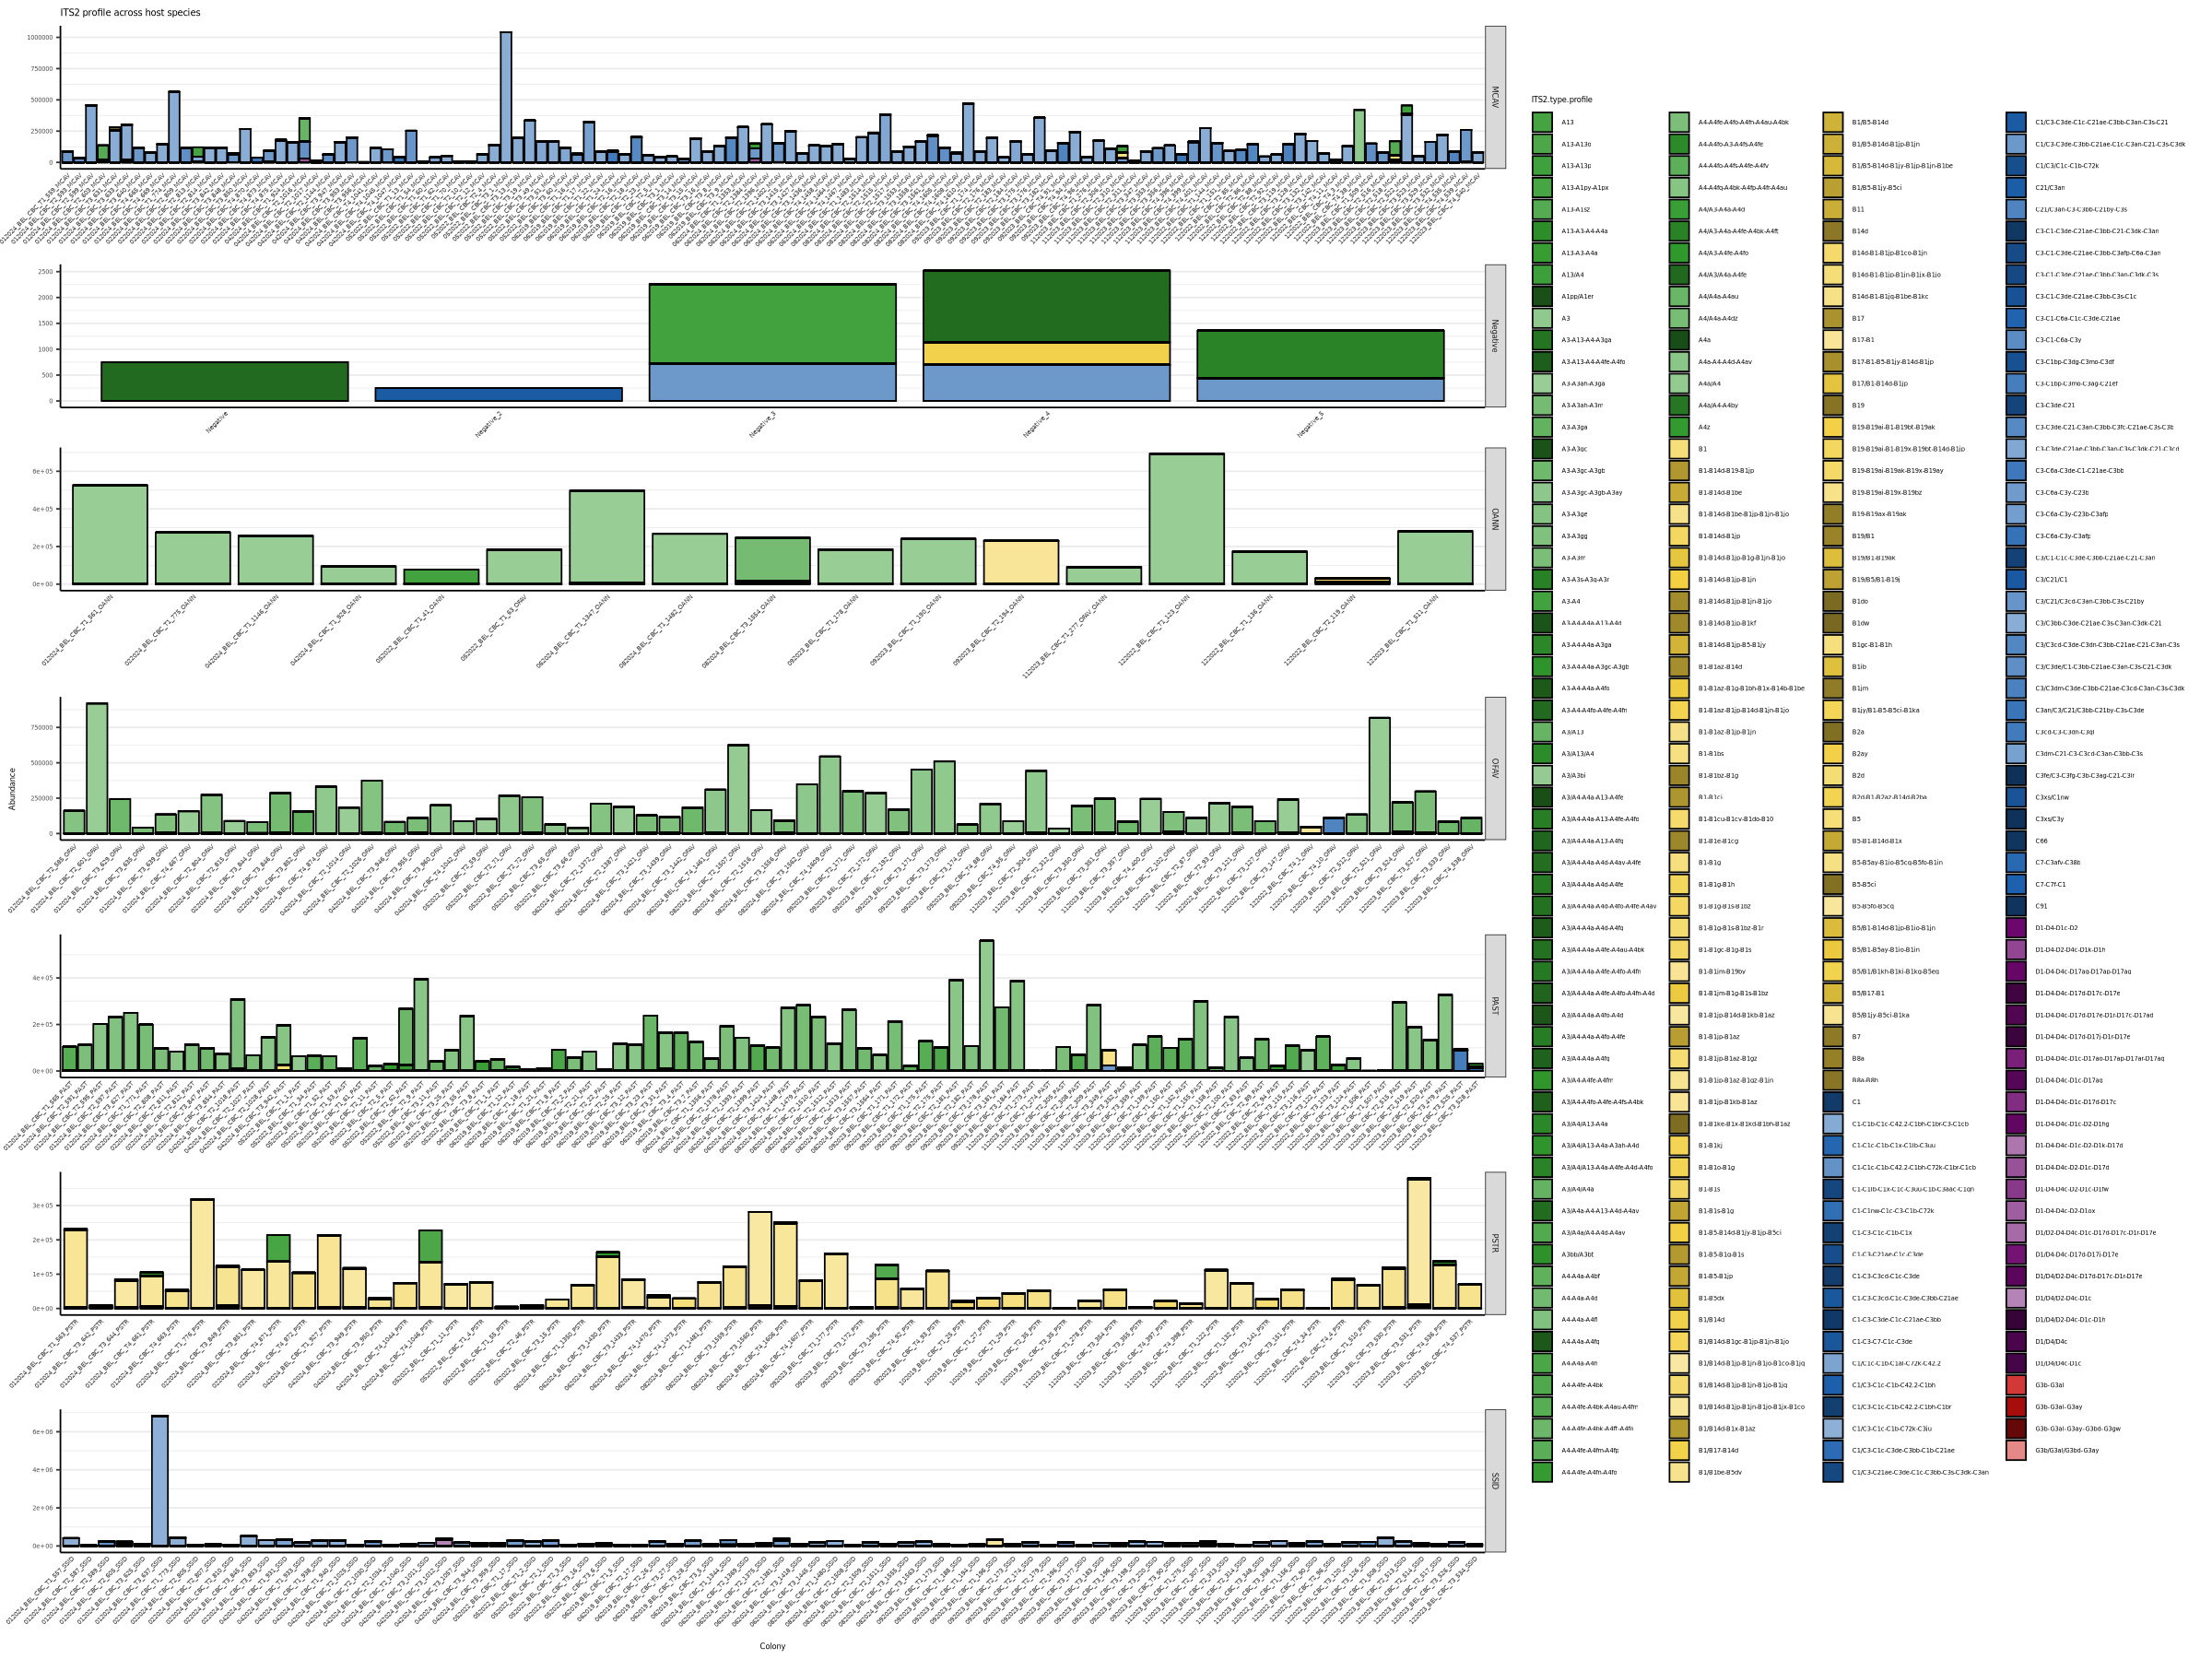

In [102]:
sam_profile <- plot_bar(ps_col, fill = "ITS2.type.profile") +
  facet_wrap(Species ~., strip.position = "right", ncol = 1, scales = "free") + 
  labs(title = "ITS2 profile across host species",
       x = "Colony",
       y = "Abundance",
       fill = "ITS2.type.profile") + # Changed 'color' to 'fill' to match plot_bar
  scale_fill_manual(values = profile_colors, drop = TRUE) +
  scale_color_manual(values = profile_colors, drop = TRUE) +
  theme_bw() +
  theme(
    strip.text = element_text(size = 5), 
    legend.position = "right",
    legend.title = element_text(size = 5),
    legend.text = element_text(size = 4),          # Slightly smaller font for 100 items
    legend.key.width = unit(0.5, "cm"),            # DRAMATICALLY REDUCED (was 1.3cm)
    legend.key.height = unit(0.5, "cm"),           # DRAMATICALLY REDUCED (was 1.7cm)
    legend.spacing.x = unit(0.3, "cm"),            # Tighten spacing between keys
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 5)
  ) +                                              # Added the missing plus sign here
  guides(
    fill = guide_legend(ncol = 4, override.aes = list(size = 2)), # Wraps legend into 4 columns
    color = "none"                                 # Hides duplicate color legend if it appears
  )

sam_profile

## each species gets its out time series plot

In [103]:
#new dataframes for each species 
ps_mcav <- subset_samples(ps_col, Species == "MCAV")
ps_pstr <- subset_samples(ps_col, Species == "PSTR")
ps_ofav <- subset_samples(ps_col, Species == "OFAV")
ps_ssid <- subset_samples(ps_col, Species == "SSID")
ps_oann <- subset_samples(ps_col, Species == "OANN")
ps_past <- subset_samples(ps_col, Species == "PAST") 

## past

If your otu_table is currently raw counts, this will grab the top 25 by absolute abundance. If your samples have highly variable read depths, you might want to transform your counts to relative abundance (transform_sample_counts(ps_past, function(x) x / sum(x))) before running the code above so a single high-depth sample doesn't skew your top 25 list

In [104]:
# Identify the top 25 most abundant asvs
# the symportal asvs are based on ITS2.type.profile (both have 251 unique values)


top100_names <- names(sort(taxa_sums(ps_past), decreasing = TRUE))[1:100]

# 2. Prune the original phyloseq object to keep only those top 25
ps_past_100 <- prune_taxa(top100_names, ps_past)

# 3. (Optional) Verify your new object has exactly 25 taxa
ntaxa(ps_past_100)

[1] 100

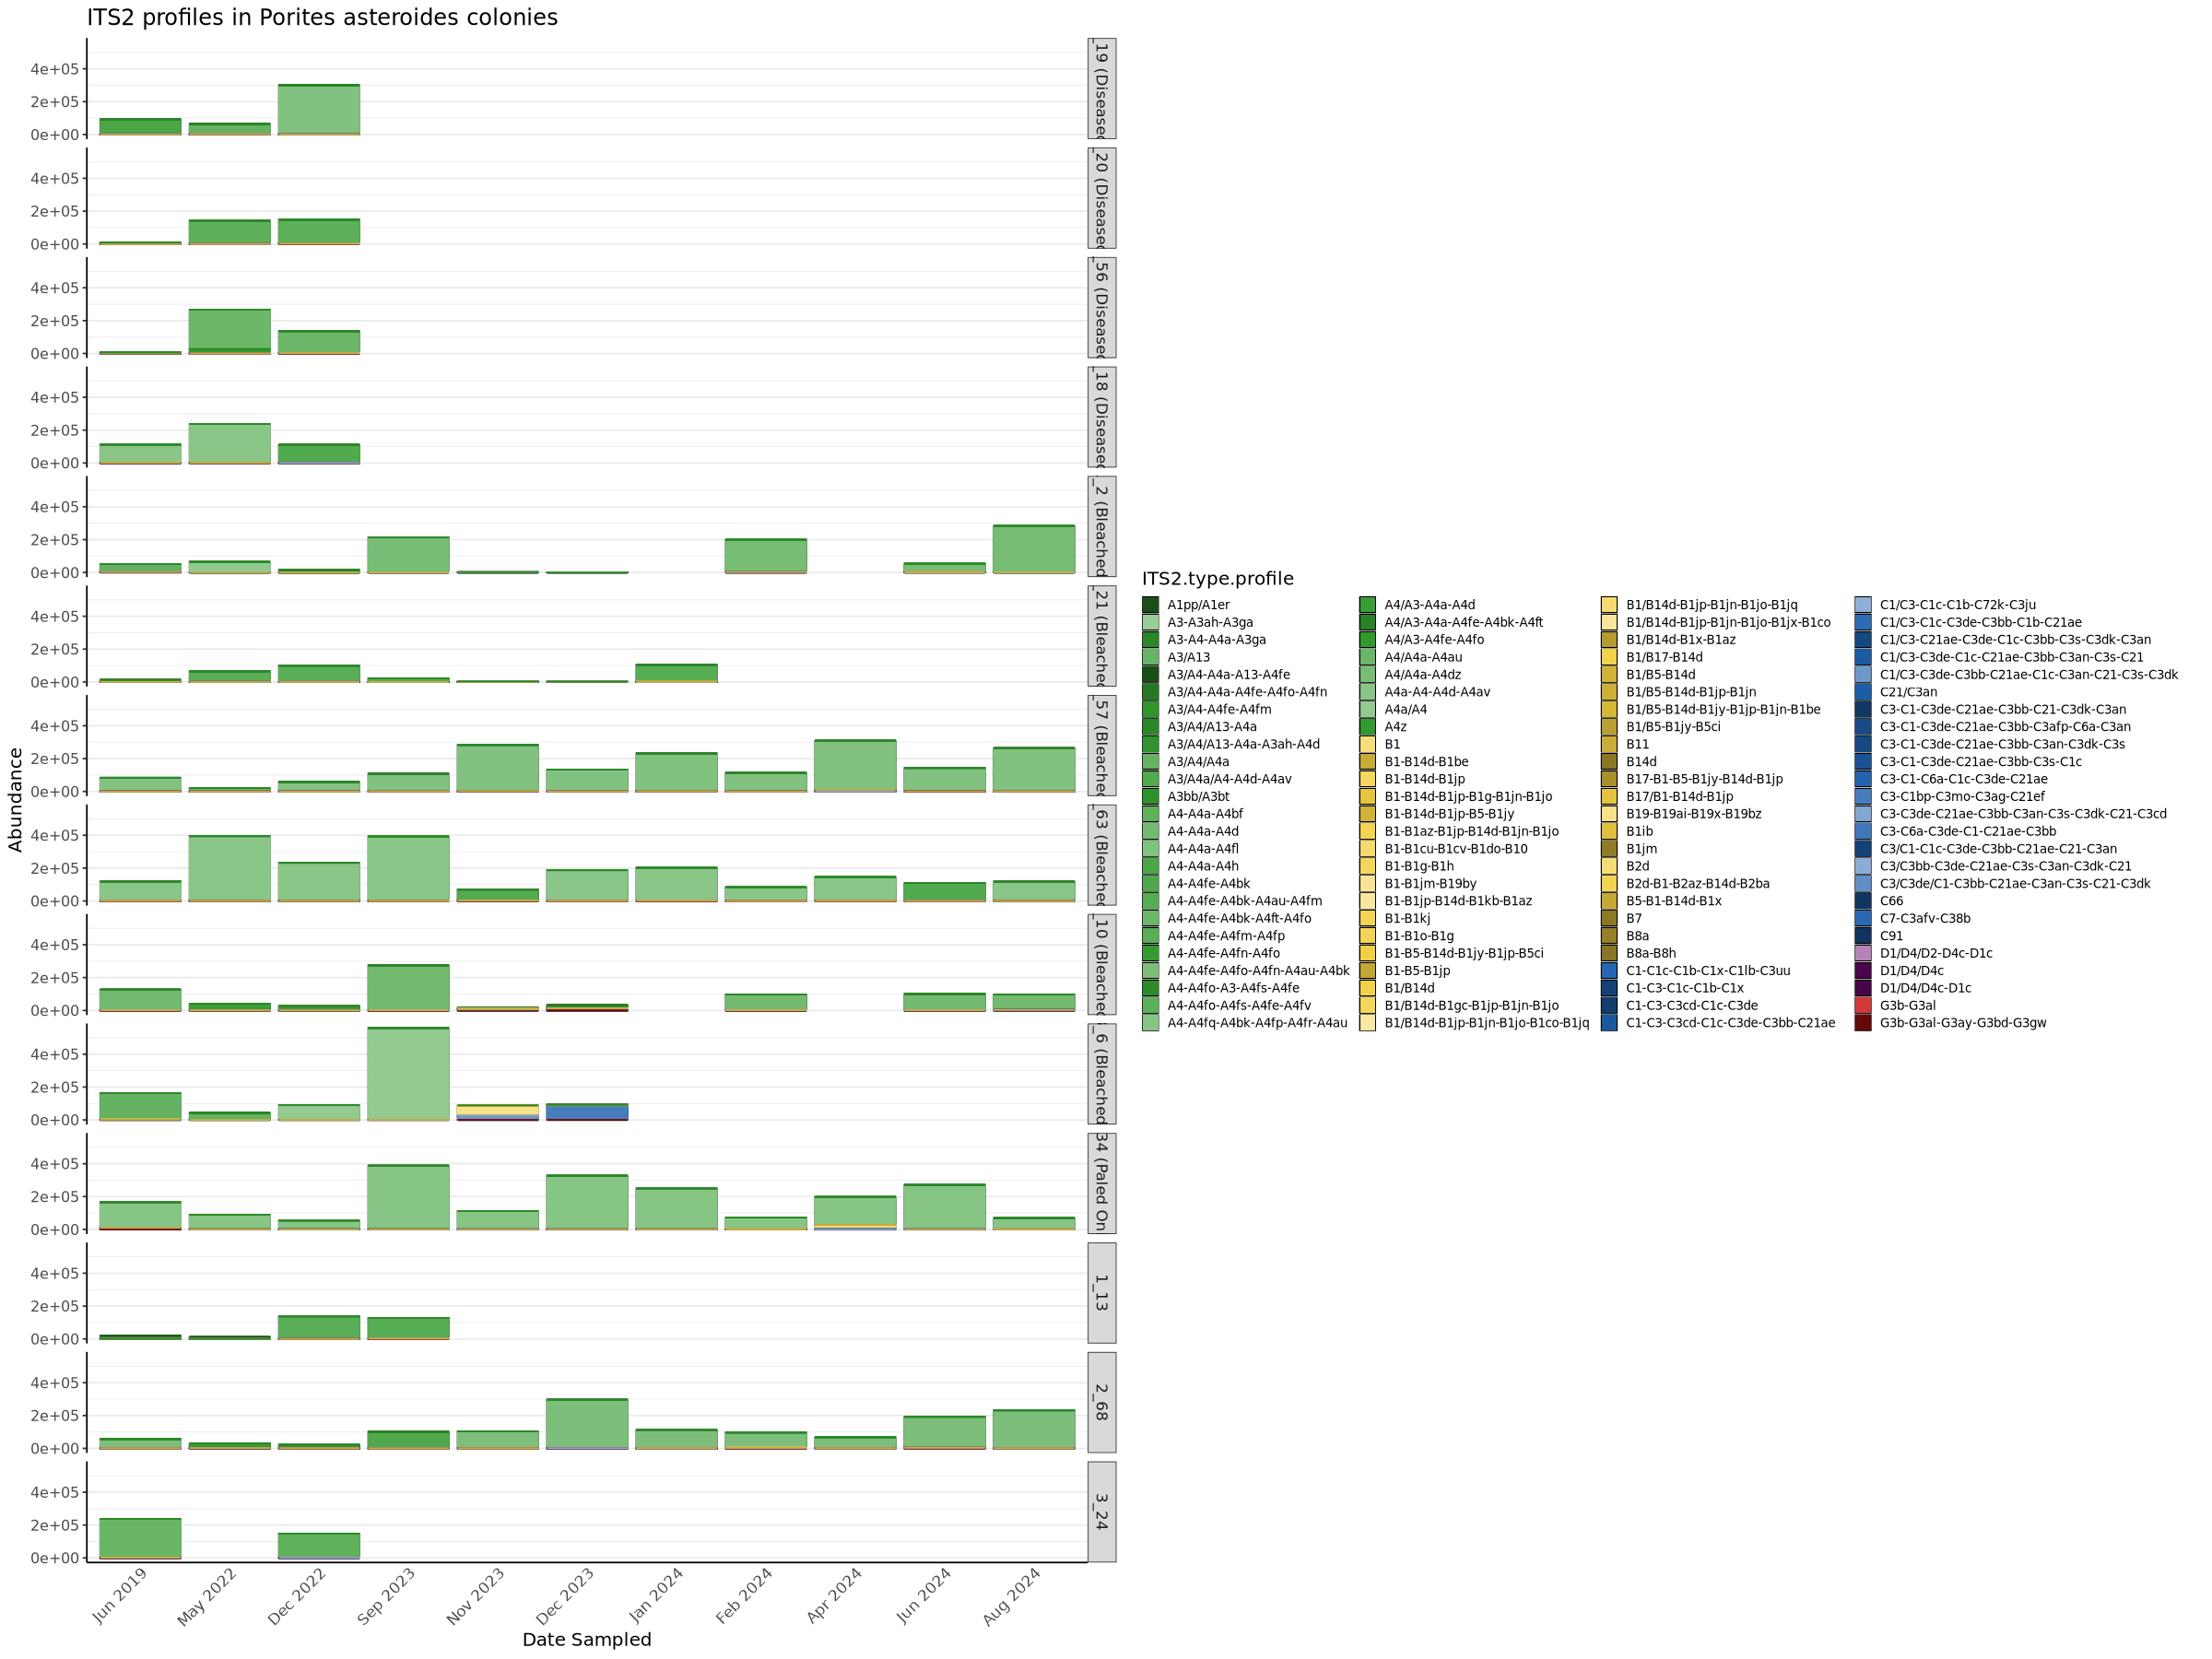

In [111]:
past_100 <- plot_bar(ps_past_100, x = "Month_year", fill = "ITS2.type.profile") +
  facet_wrap(colony_labeled ~ ., strip.position = "right", ncol = 1) + 
  geom_bar(aes(color = ITS2.type.profile, fill = ITS2.type.profile), 
           stat = "identity", position = "stack") +
  labs(title = "ITS2 profiles in Porites asteroides colonies",
       x = "Date Sampled",
       y = "Abundance",
       fill = "ITS2.type.profile") +                 # Changed to fill to match the primary aesthetic
  scale_fill_manual(values = profile_colors, drop = TRUE) +
  scale_color_manual(values = profile_colors, drop = TRUE) +
  theme_bw() +
  theme(
    strip.text = element_text(size = 10), 
    legend.position = "right",
    legend.box = "horizontal",                      # Ensures the legend layout behaves as a block
    legend.title = element_text(size = 12),
    legend.text = element_text(size = 8),           # Slightly reduced to create massive plot breathing room
    legend.key.width = unit(0.4, "cm"),  
    legend.key.height = unit(0.4, "cm"), 
    legend.spacing.x = unit(0.2, "cm"), 
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1, size = 10),
    text = element_text(size = 12)                  # Balanced overall text sizing
  ) +                                               # Added the critical missing plus sign
  guides(
    fill = guide_legend(ncol = 4, override.aes = list(size = 4)), # Wraps into 4 columns to keep it compact on the right
    color = "none"                                  # Shuts off the duplicate color legend outline
  )

past_100

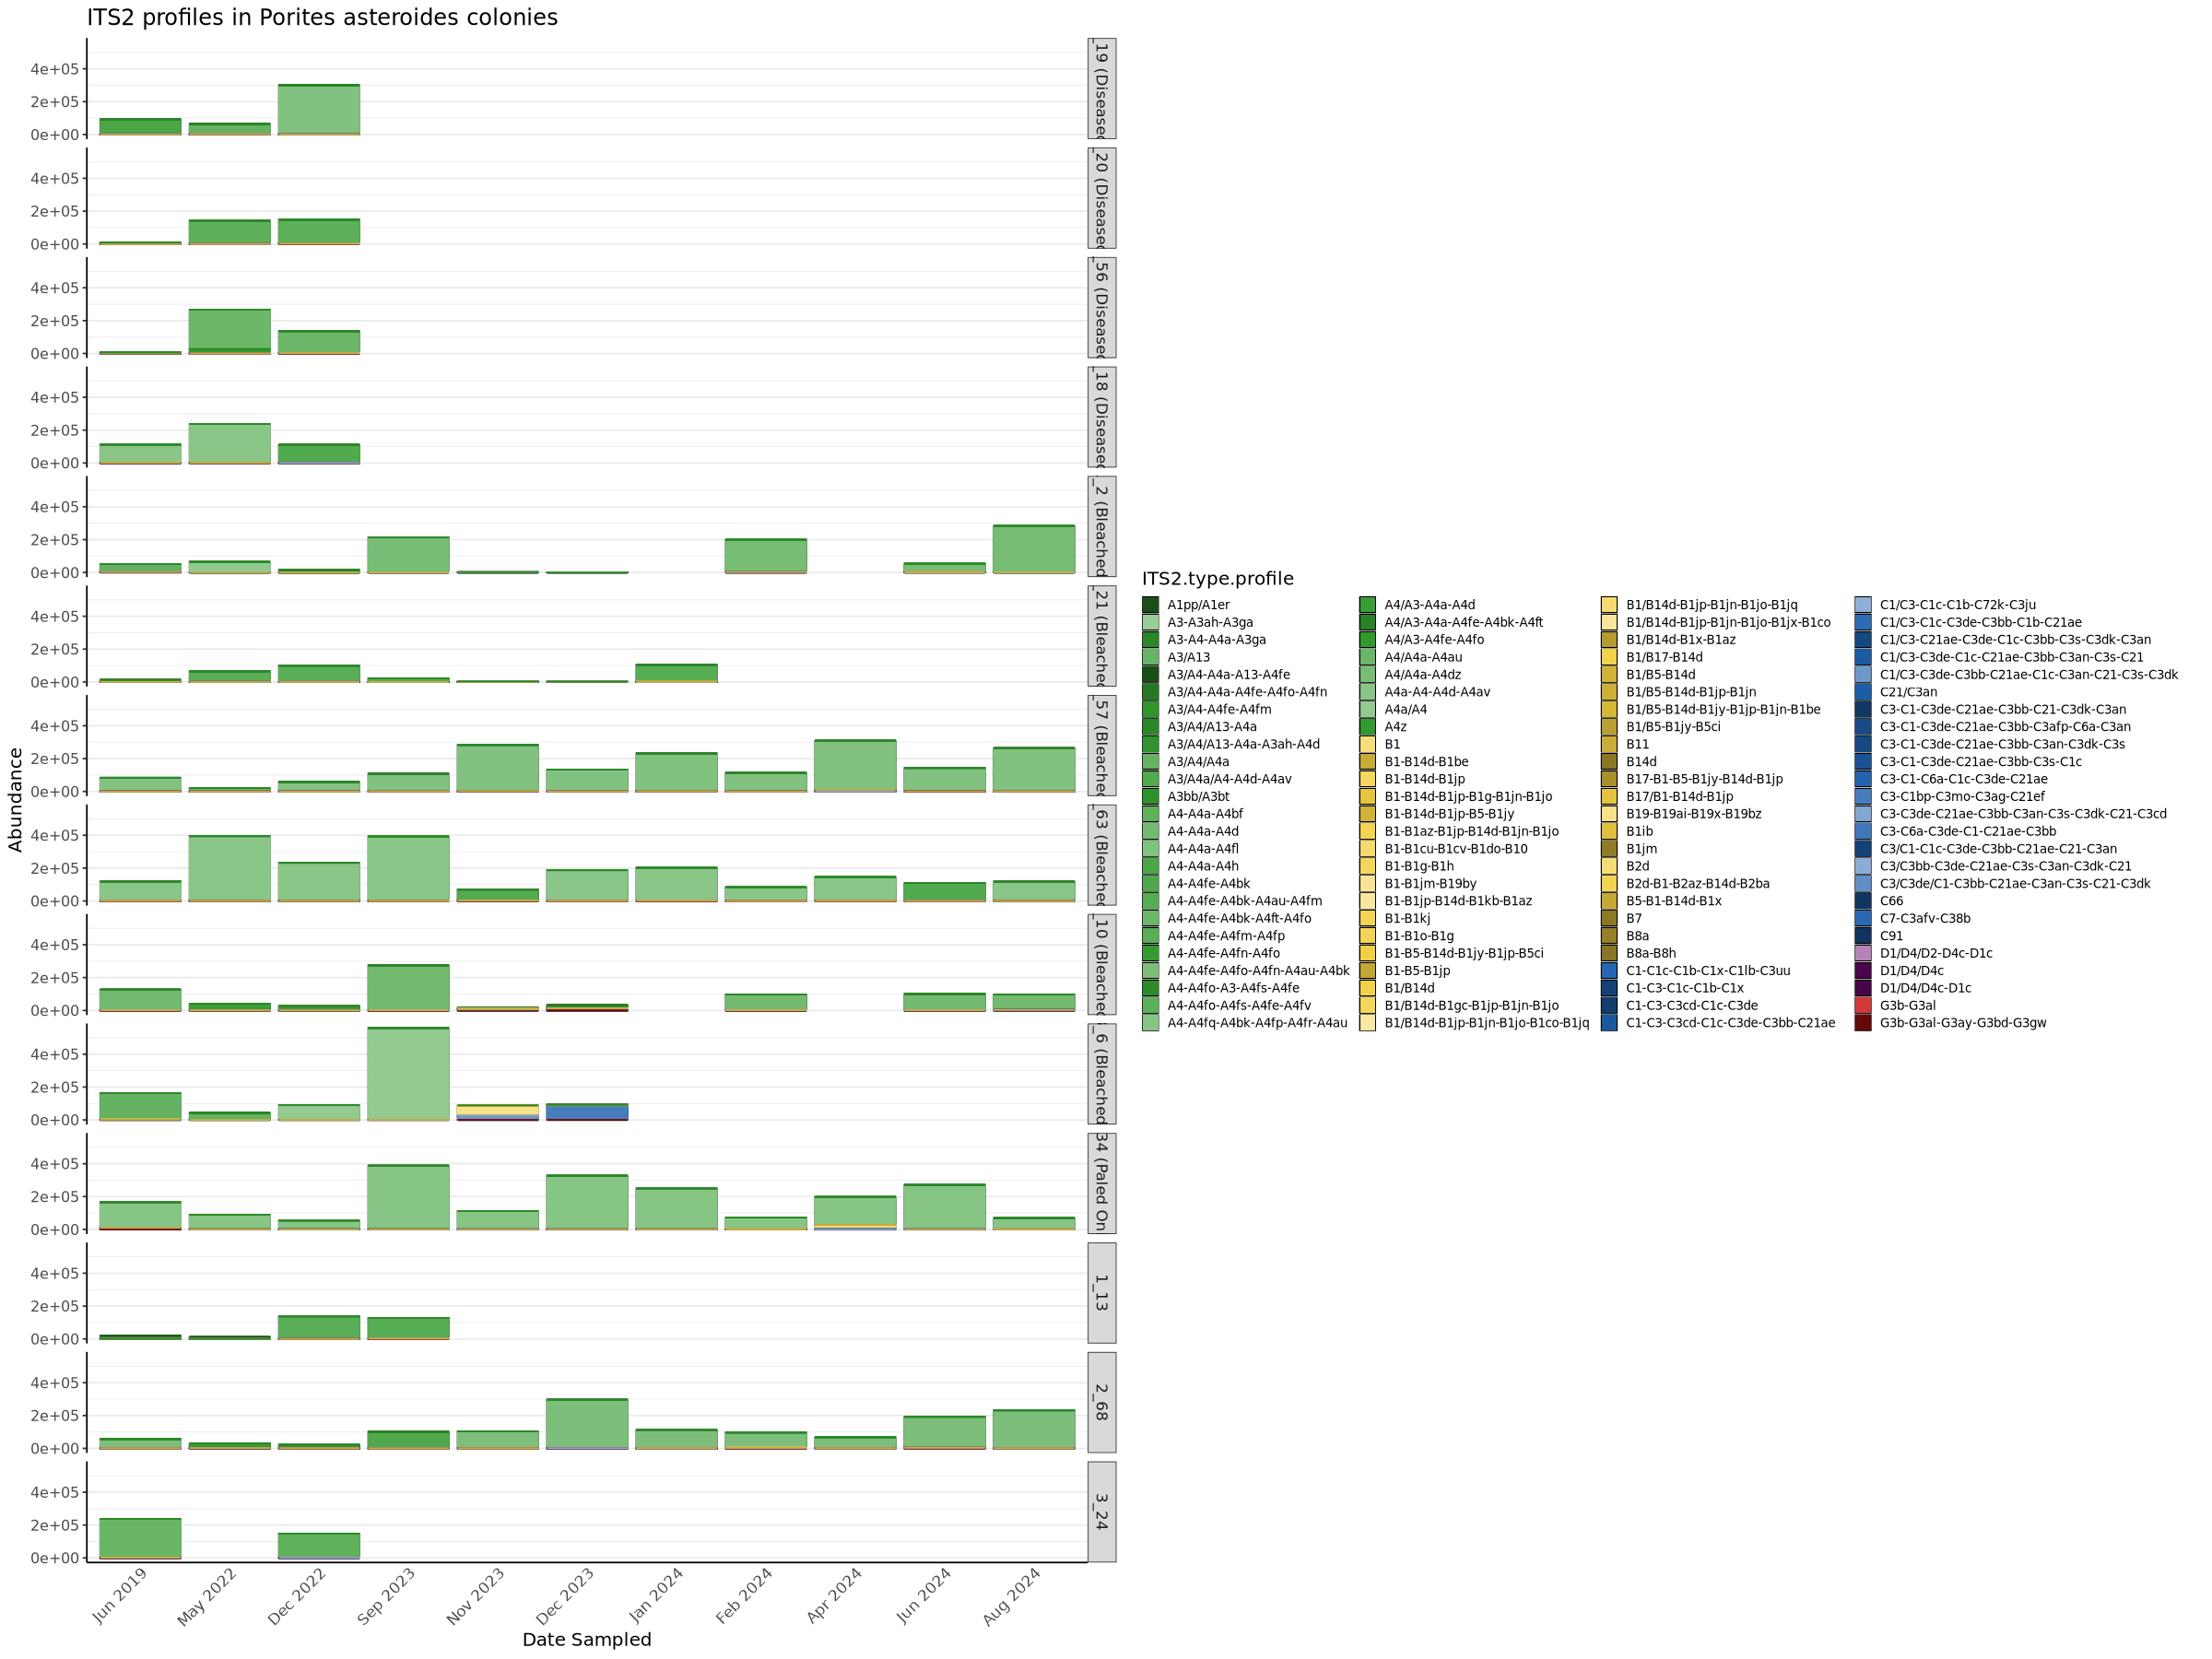

In [110]:
past_all <- plot_bar(ps, x = "Month_year", fill = "ITS2.type.profile") +
  facet_wrap(colony_labeled ~ ., strip.position = "right", ncol = 1) + 
  geom_bar(aes(color = ITS2.type.profile, fill = ITS2.type.profile), 
           stat = "identity", position = "stack") +
  labs(title = "ITS2 profiles in Porites asteroides colonies",
       x = "Date Sampled",
       y = "Abundance",
       fill = "ITS2.type.profile") +                 # Changed to fill to match the primary aesthetic
  scale_fill_manual(values = profile_colors, drop = TRUE) +
  scale_color_manual(values = profile_colors, drop = TRUE) +
  theme_bw() +
  theme(
    strip.text = element_text(size = 10), 
    legend.position = "right",
    legend.box = "horizontal",                      # Ensures the legend layout behaves as a block
    legend.title = element_text(size = 12),
    legend.text = element_text(size = 8),           # Slightly reduced to create massive plot breathing room
    legend.key.width = unit(0.4, "cm"),  
    legend.key.height = unit(0.4, "cm"), 
    legend.spacing.x = unit(0.2, "cm"), 
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1, size = 10),
    text = element_text(size = 12)                  # Balanced overall text sizing
  ) +                                               # Added the critical missing plus sign
  guides(
    fill = guide_legend(ncol = 4, override.aes = list(size = 4)), # Wraps into 4 columns to keep it compact on the right
    color = "none"                                  # Shuts off the duplicate color legend outline
  )

past

## pstr

In [106]:
# Identify the top 25 most abundant asvs
# the symportal asvs are based on ITS2.type.profile (both have 251 unique values)

top100_names_pstr <- names(sort(taxa_sums(ps_pstr), decreasing = TRUE))[1:100]

# 2. Prune the original phyloseq object to keep only those top 25
ps_pstr_100 <- prune_taxa(top100_names_pstr, ps_pstr)

# 3. (Optional) Verify your new object has exactly 25 taxa
ntaxa(ps_pstr_100)

[1] 100

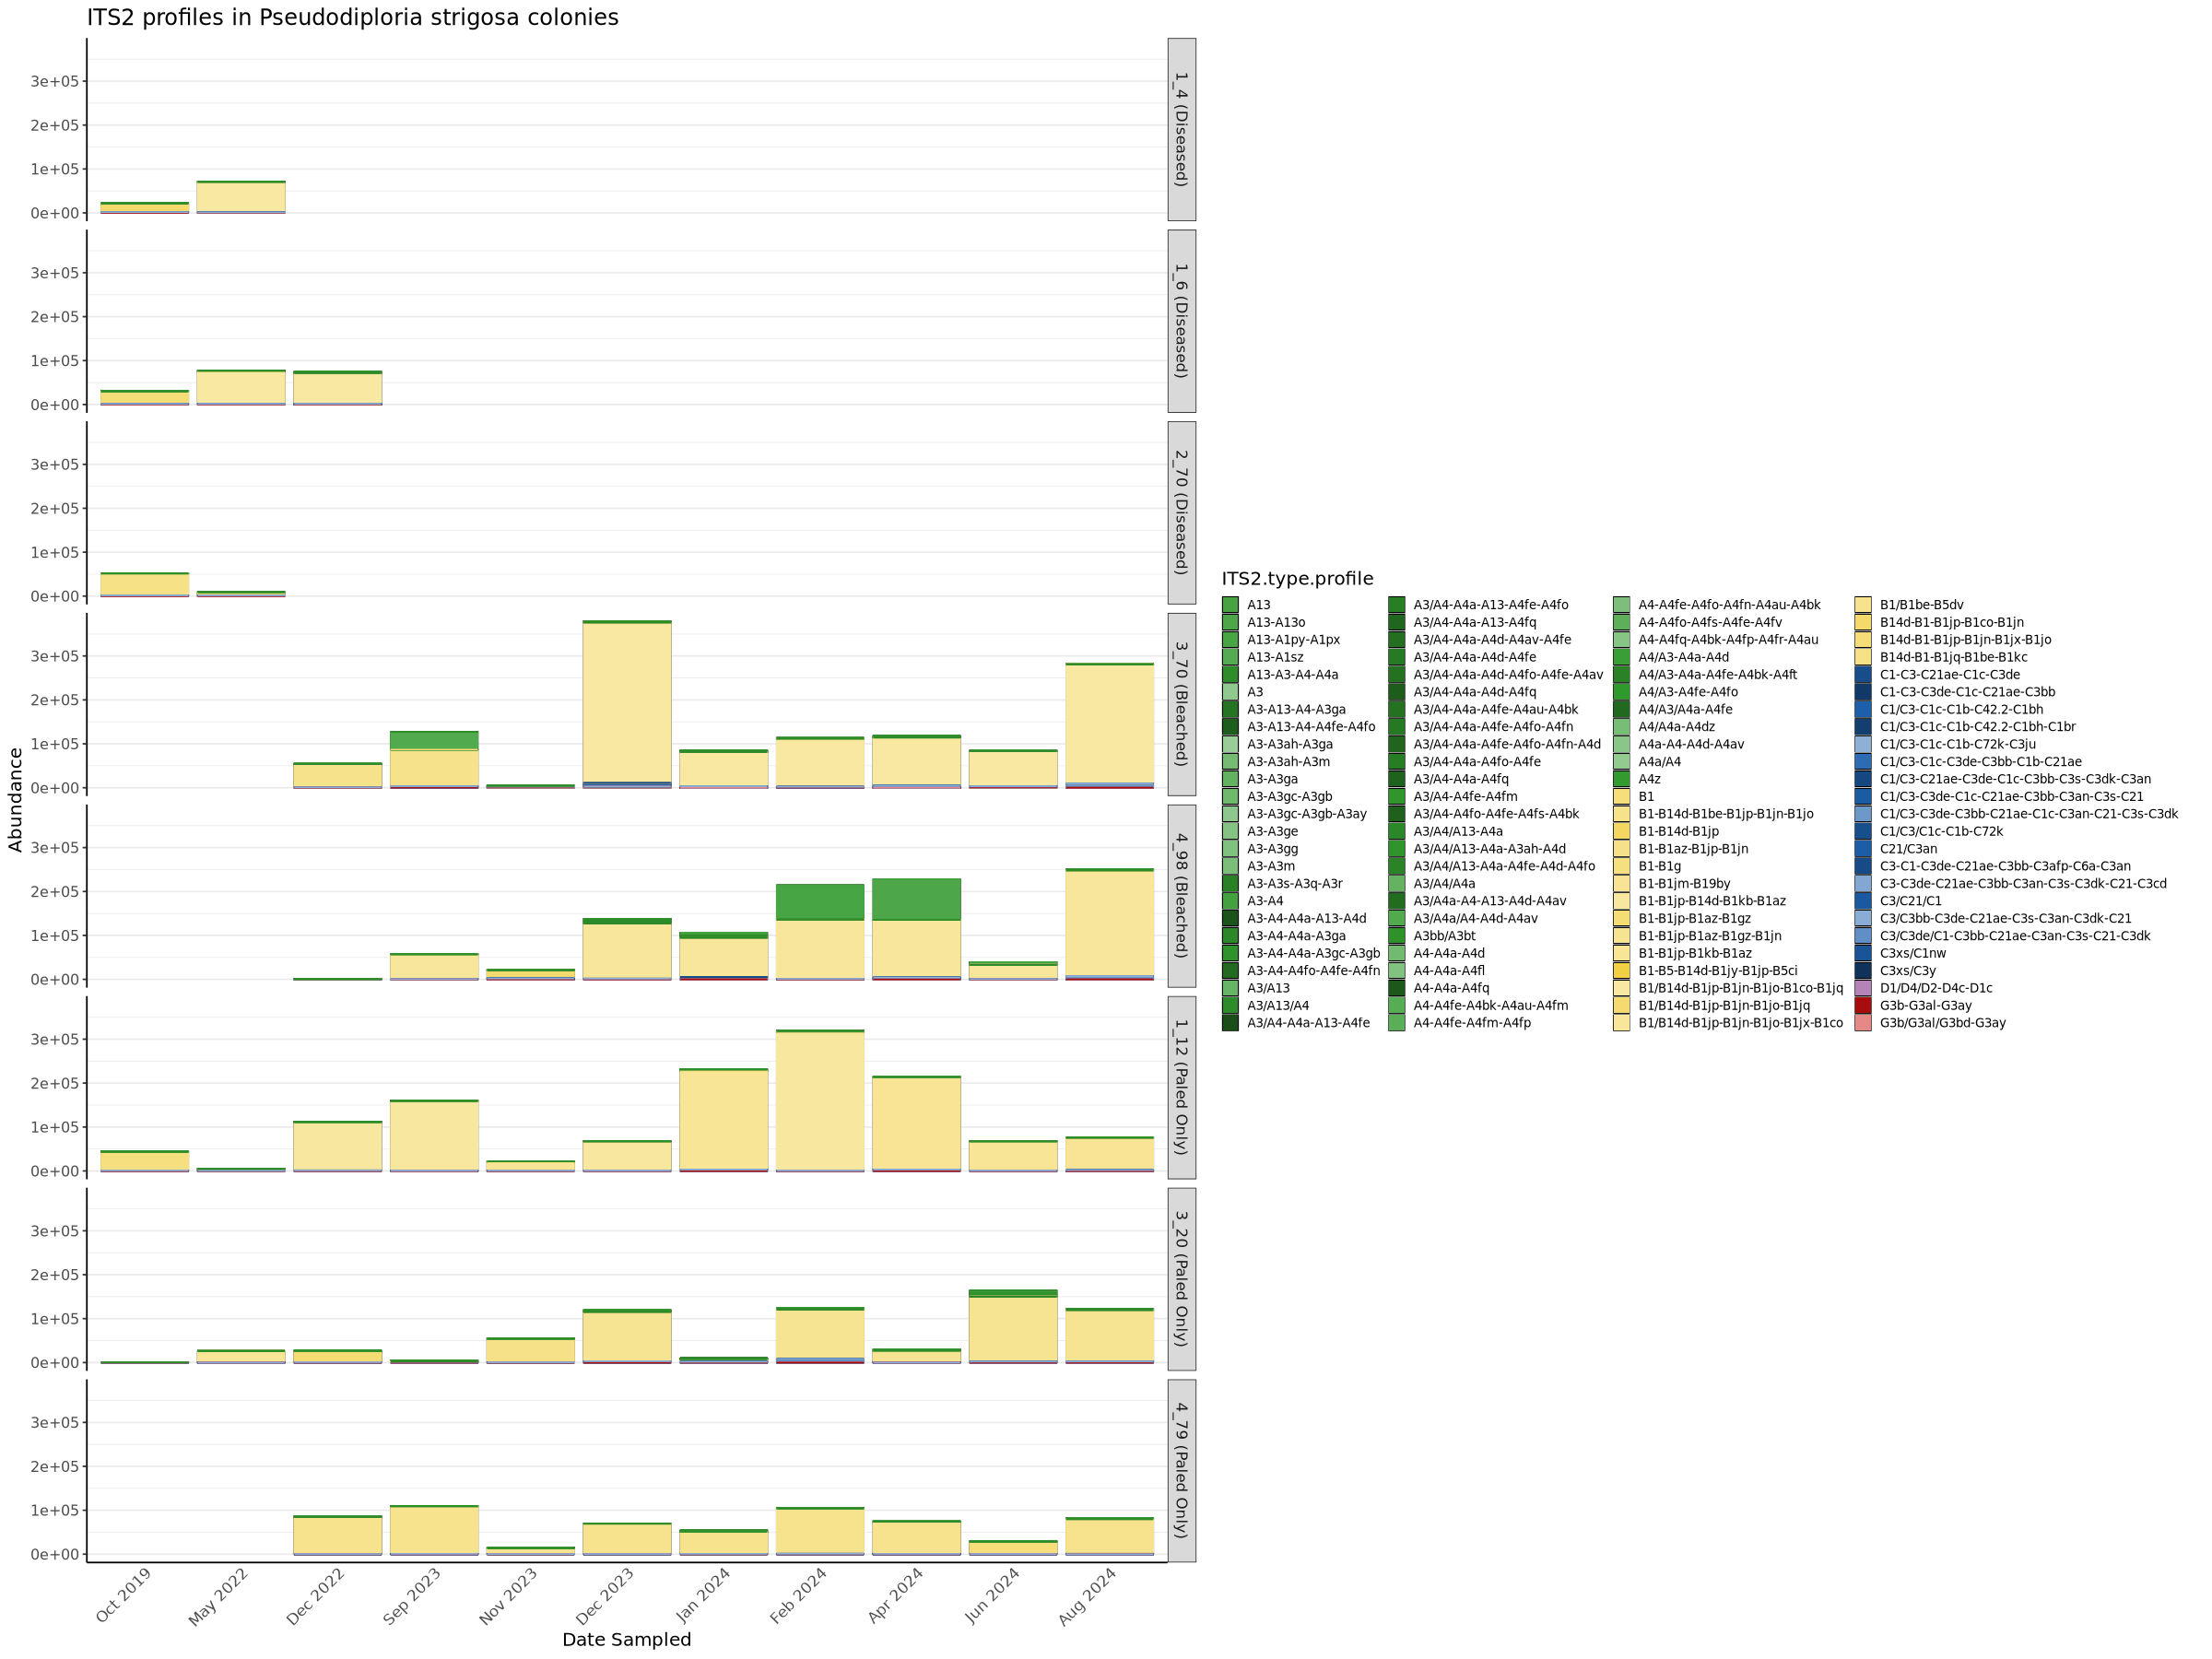

In [107]:
pstr= plot_bar(ps_pstr_100, x= "Month_year", fill = "ITS2.type.profile") +
facet_wrap(colony_labeled ~., strip.position = "right",  ncol = 1) + # Set desired font size
geom_bar(aes(color = ITS2.type.profile, fill = ITS2.type.profile), 
           stat = "identity", position = "stack") +
  labs(title = "ITS2 profiles in Pseudodiploria strigosa colonies",
       x = "Date Sampled",
       y = "Abundance",
       color = "ITS2.type.profile") +
    scale_fill_manual(values = profile_colors, drop = TRUE) +
  scale_color_manual(values = profile_colors, drop = TRUE) +
  theme_bw() +
  theme(
    strip.text = element_text(size = 10), 
    legend.position = "right",
    legend.box = "horizontal",                      # Ensures the legend layout behaves as a block
    legend.title = element_text(size = 12),
    legend.text = element_text(size = 8),           # Slightly reduced to create massive plot breathing room
    legend.key.width = unit(0.4, "cm"),  
    legend.key.height = unit(0.4, "cm"), 
    legend.spacing.x = unit(0.2, "cm"), 
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1, size = 10),
    text = element_text(size = 12)                  # Balanced overall text sizing
  ) +                                               # Added the critical missing plus sign
  guides(
    fill = guide_legend(ncol = 4, override.aes = list(size = 4)), # Wraps into 4 columns to keep it compact on the right
    color = "none"                                  # Shuts off the duplicate color legend outline
  )
pstr

## mcav

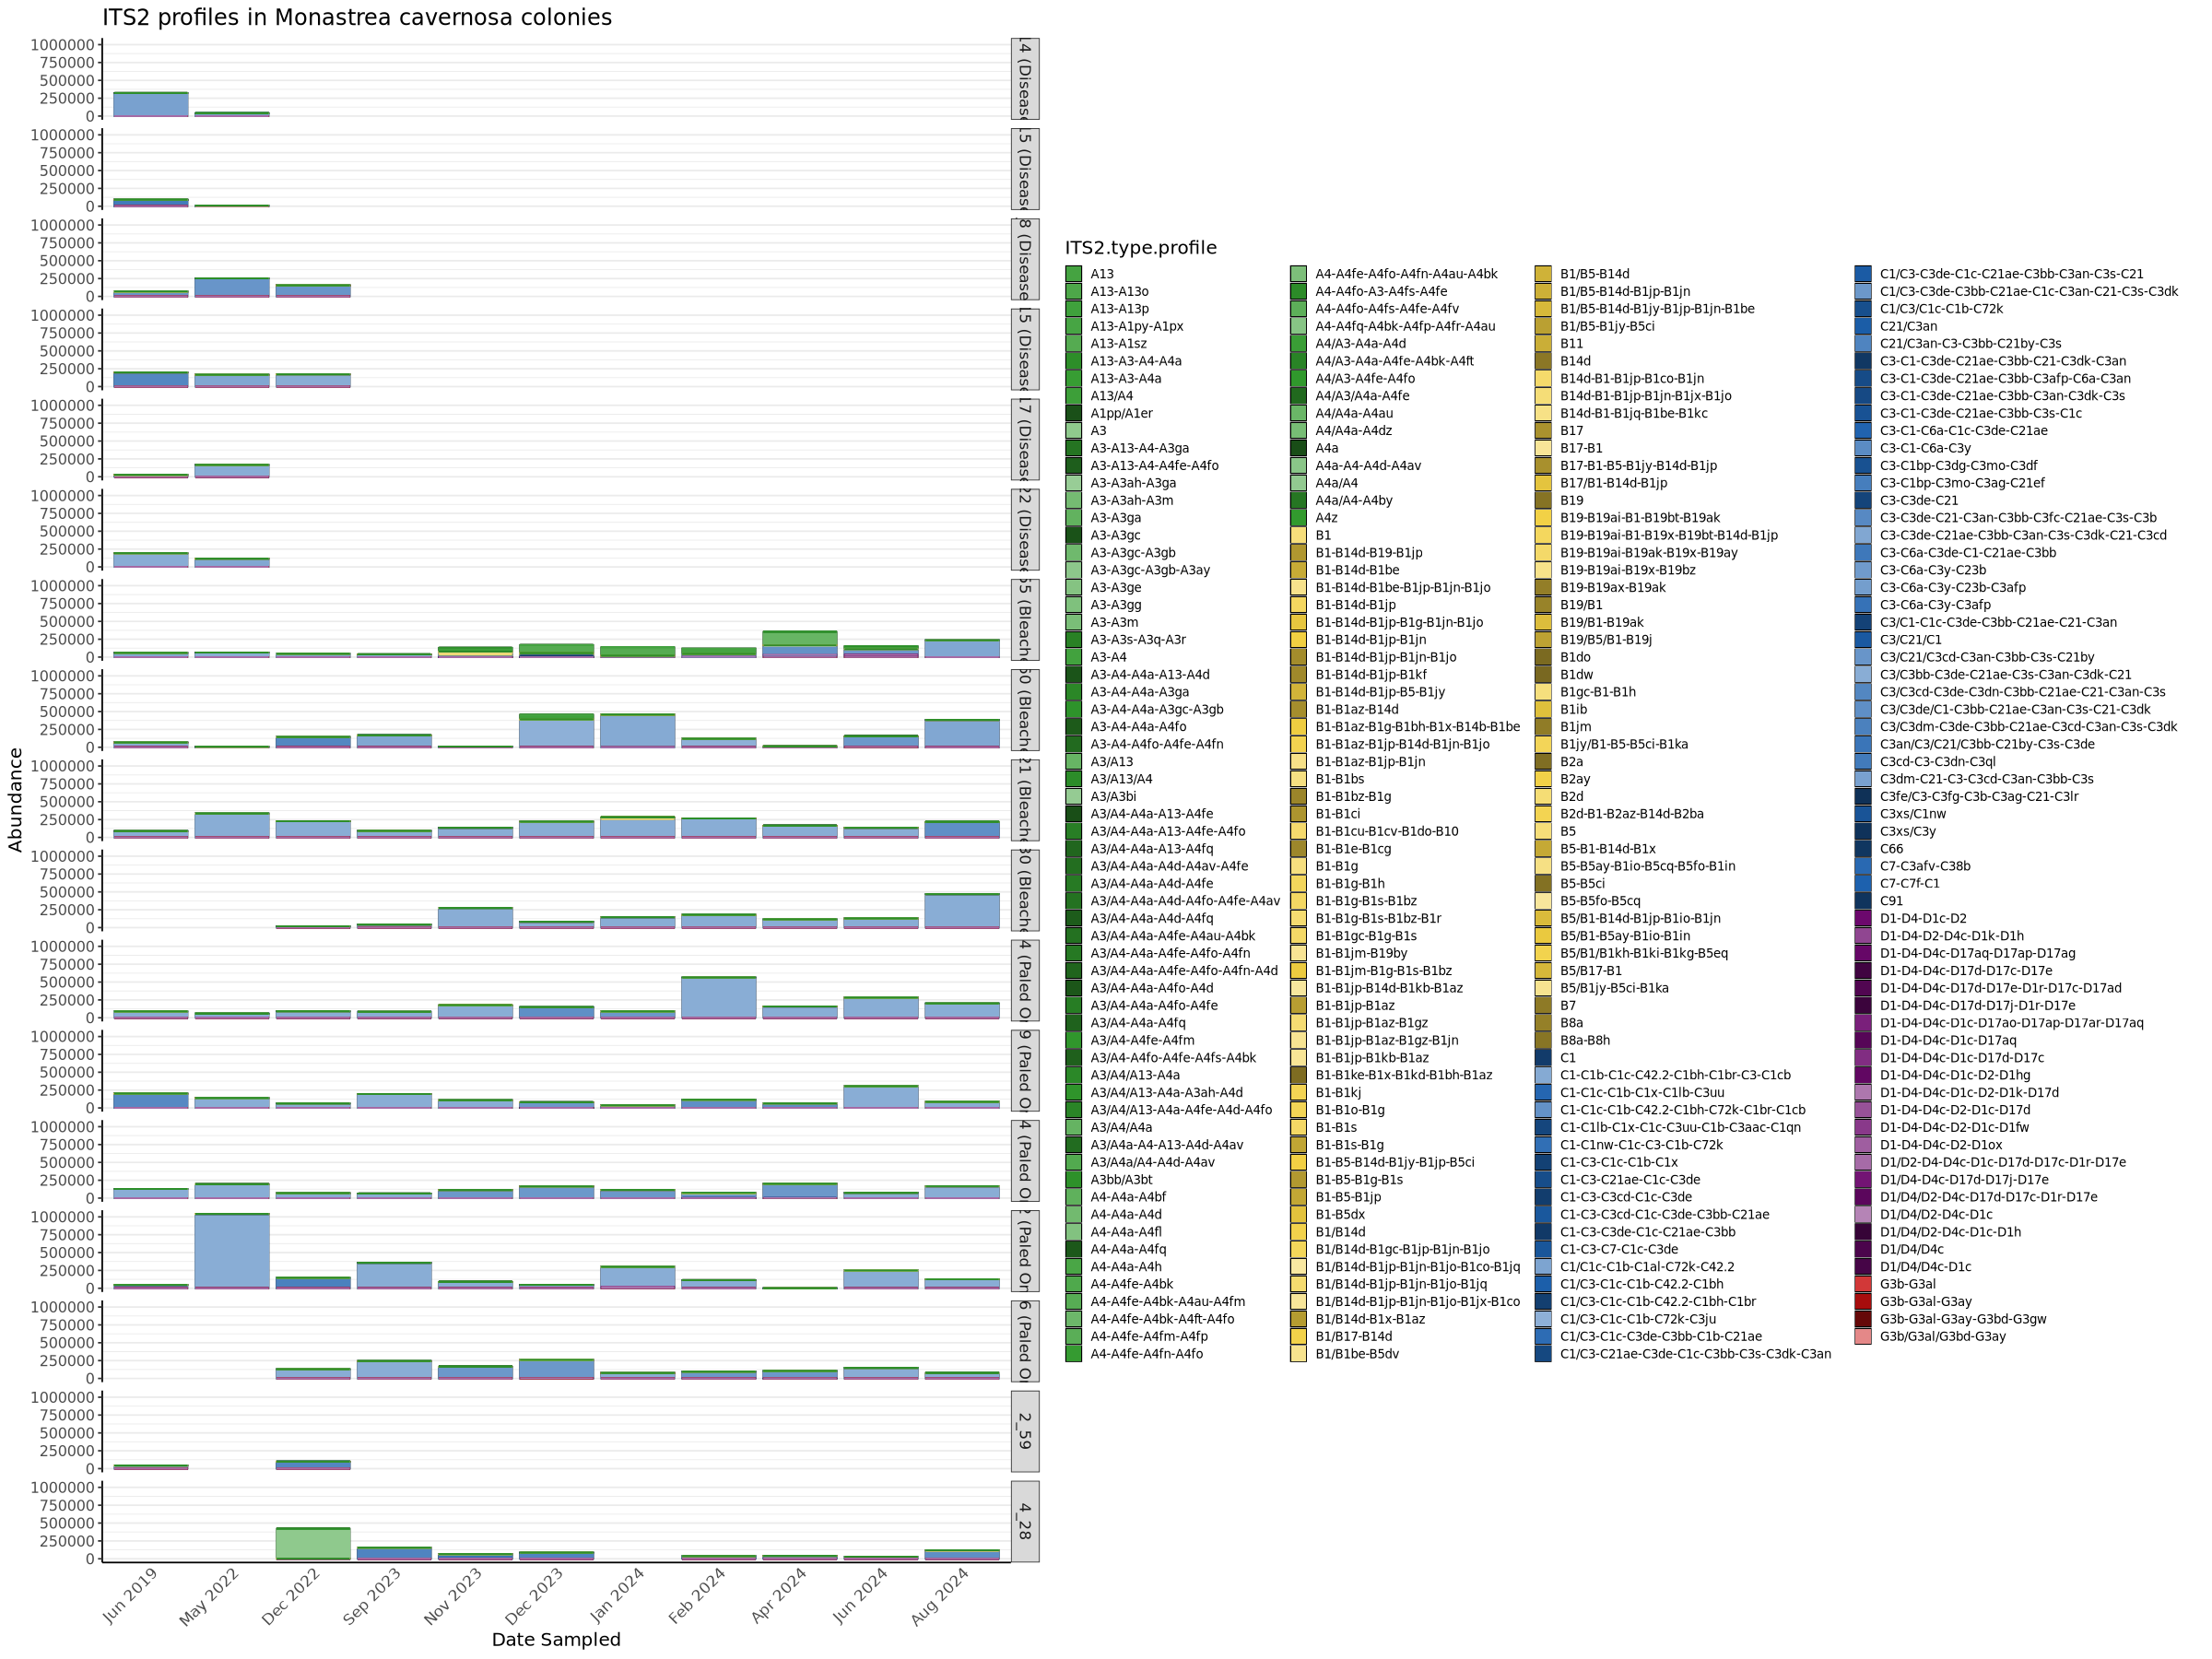

In [108]:
mcav= plot_bar(ps_mcav, x= "Month_year", fill = "ITS2.type.profile") +
facet_wrap(colony_labeled ~., strip.position = "right",  ncol = 1) + # Set desired font size
geom_bar(aes(color = ITS2.type.profile, fill = ITS2.type.profile), 
           stat = "identity", position = "stack") +
  labs(title = "ITS2 profiles in Monastrea cavernosa colonies",
       x = "Date Sampled",
       y = "Abundance",
       color = "ITS2.type.profile") +
      scale_fill_manual(values = profile_colors, drop = TRUE) +
  scale_color_manual(values = profile_colors, drop = TRUE) +
  theme_bw() +
  theme(
    strip.text = element_text(size = 10), 
    legend.position = "right",
    legend.box = "horizontal",                      # Ensures the legend layout behaves as a block
    legend.title = element_text(size = 12),
    legend.text = element_text(size = 8),           # Slightly reduced to create massive plot breathing room
    legend.key.width = unit(0.4, "cm"),  
    legend.key.height = unit(0.4, "cm"), 
    legend.spacing.x = unit(0.2, "cm"), 
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1, size = 10),
    text = element_text(size = 12)                  # Balanced overall text sizing
  ) +                                               # Added the critical missing plus sign
  guides(
    fill = guide_legend(ncol = 4, override.aes = list(size = 4)), # Wraps into 4 columns to keep it compact on the right
    color = "none"                                  # Shuts off the duplicate color legend outline
  ) 
mcav

## ssid

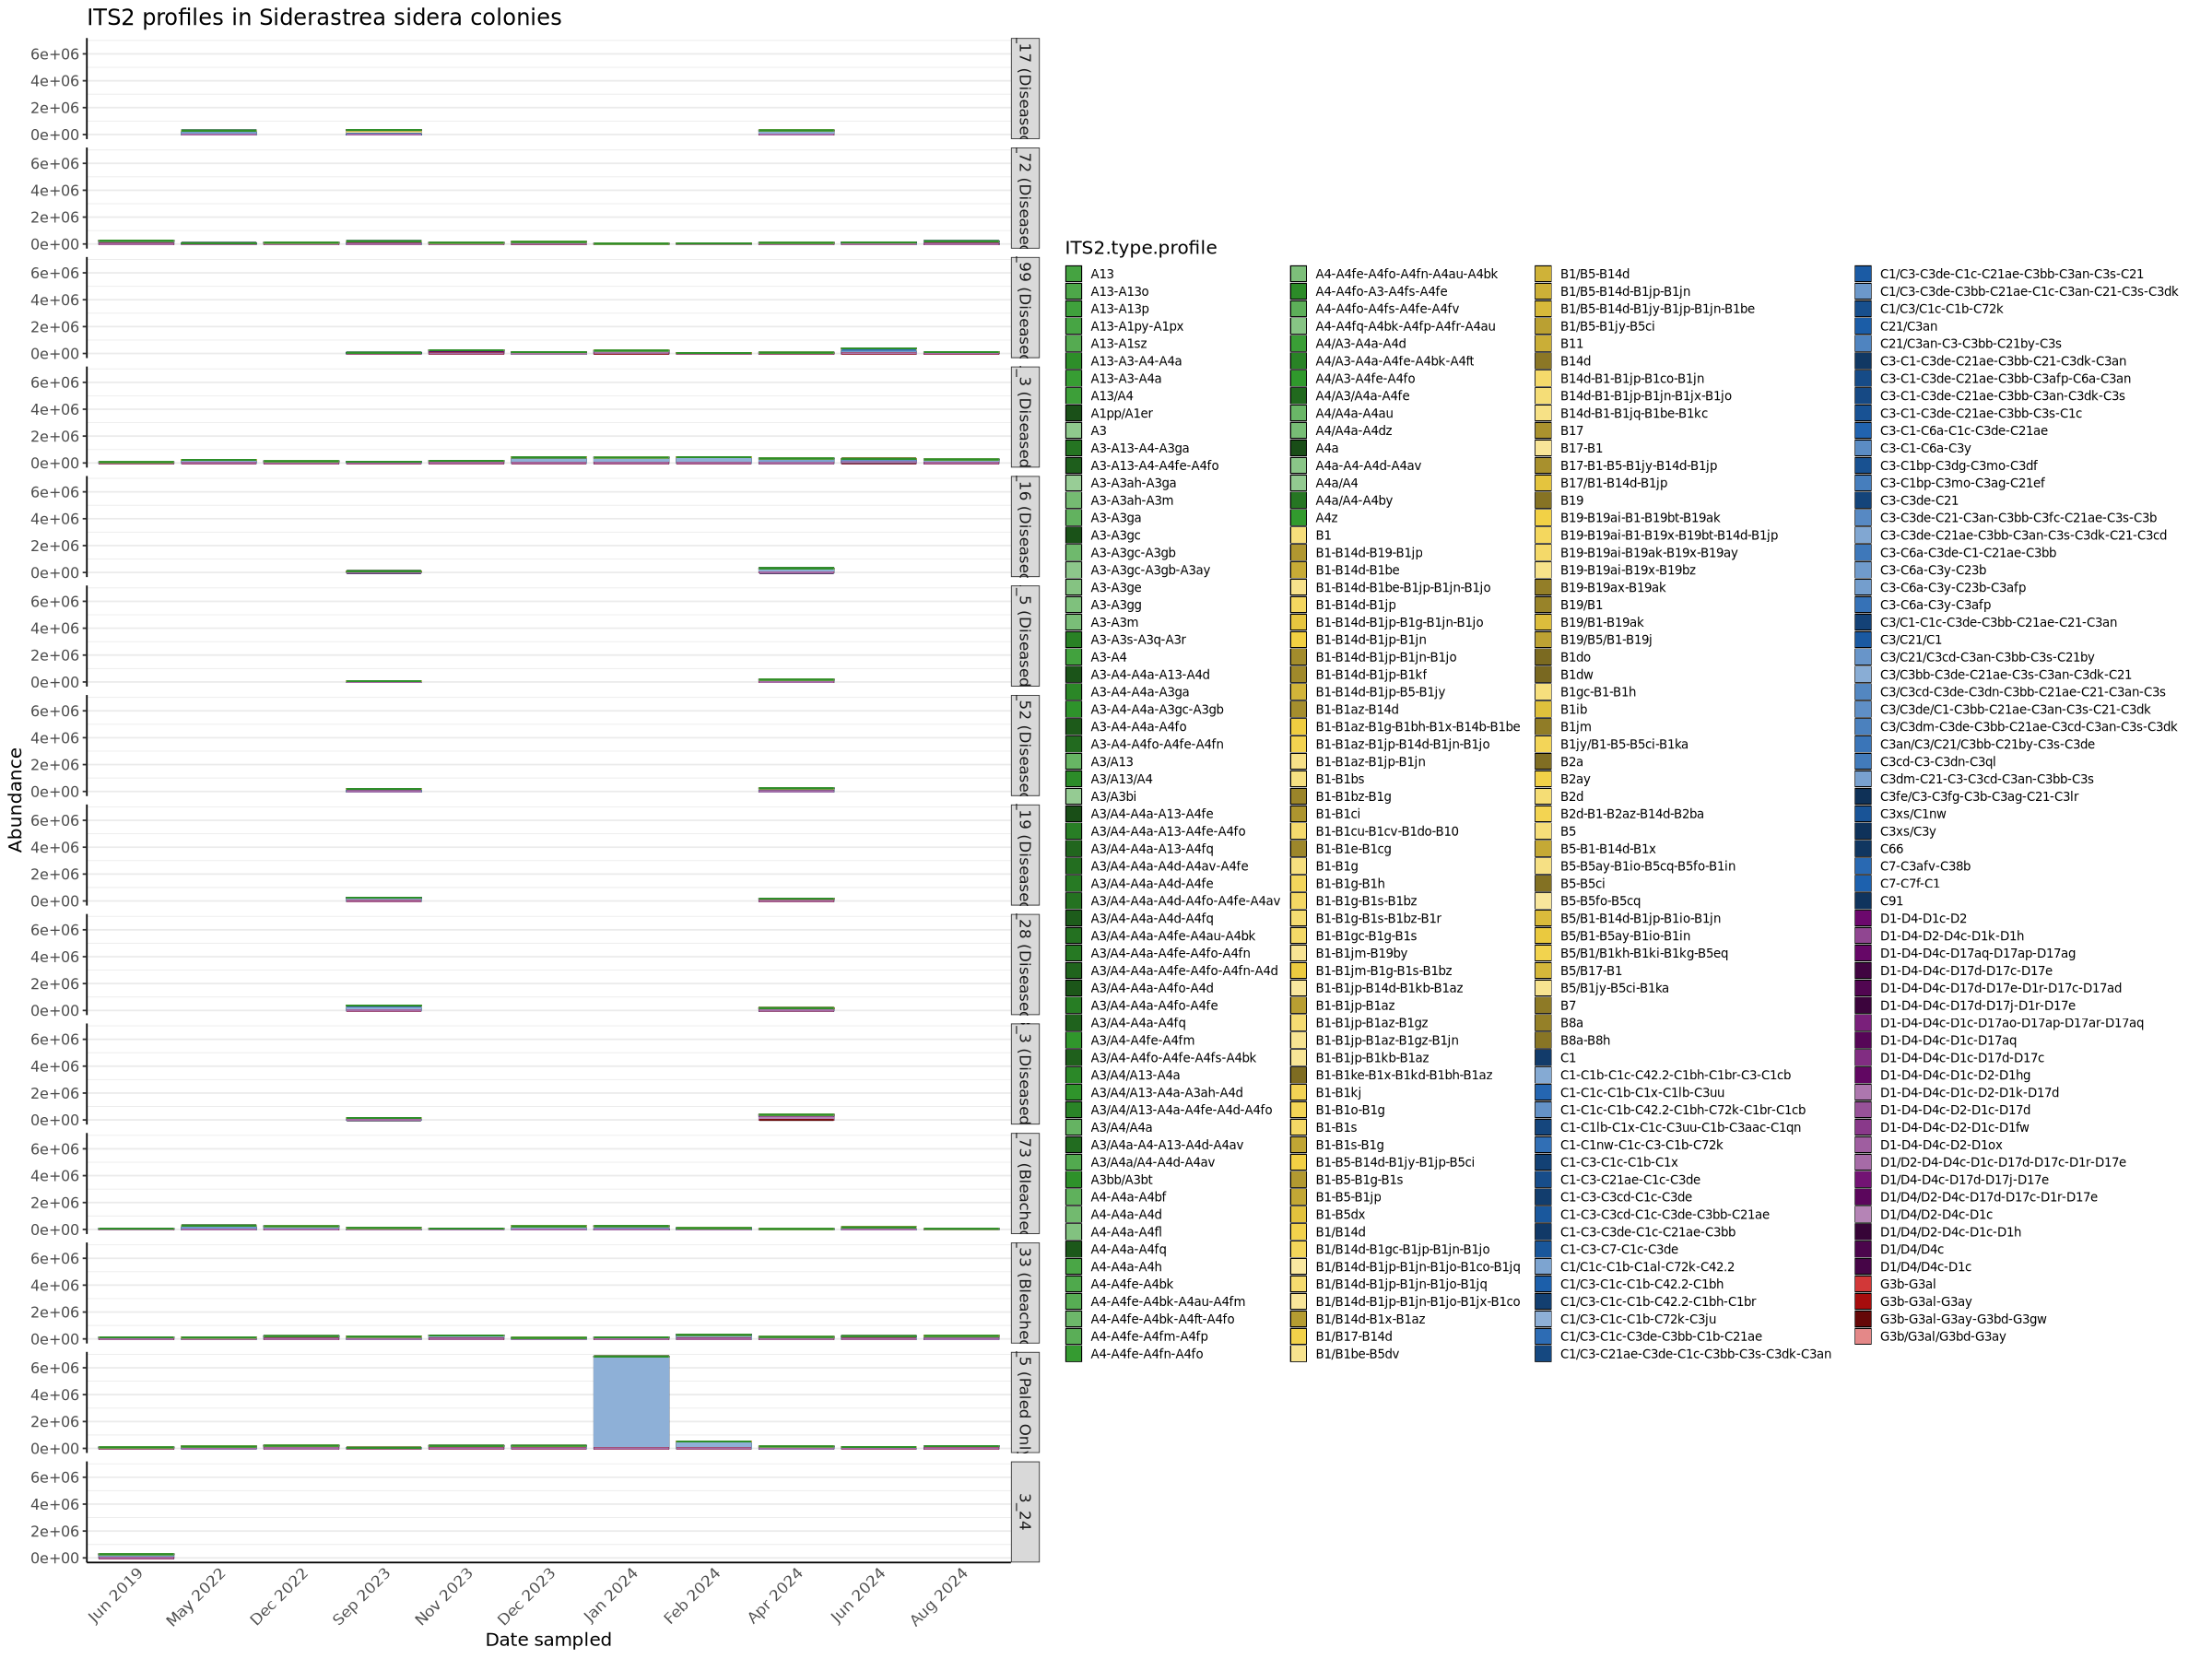

In [112]:

ssid= plot_bar(ps_ssid, x= "Month_year", fill = "ITS2.type.profile") +
facet_wrap(colony_labeled ~., strip.position = "right",  ncol = 1) + # Set desired font size
geom_bar(aes(color = ITS2.type.profile, fill = ITS2.type.profile), 
           stat = "identity", position = "stack") +
  labs(title = "ITS2 profiles in Siderastrea sidera colonies",
       x = "Date sampled",
       y = "Abundance",
       color = "ITS2.type.profile") +
    scale_fill_manual(values = profile_colors, drop = TRUE) +
  scale_color_manual(values = profile_colors, drop = TRUE) +
  theme_bw() +
  theme(
    strip.text = element_text(size = 10), 
    legend.position = "right",
    legend.box = "horizontal",                      # Ensures the legend layout behaves as a block
    legend.title = element_text(size = 12),
    legend.text = element_text(size = 8),           # Slightly reduced to create massive plot breathing room
    legend.key.width = unit(0.4, "cm"),  
    legend.key.height = unit(0.4, "cm"), 
    legend.spacing.x = unit(0.2, "cm"), 
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1, size = 10),
    text = element_text(size = 12)                  # Balanced overall text sizing
  ) +                                               # Added the critical missing plus sign
  guides(
    fill = guide_legend(ncol = 4, override.aes = list(size = 4)), # Wraps into 4 columns to keep it compact on the right
    color = "none"                                  # Shuts off the duplicate color legend outline
  ) 
ssid

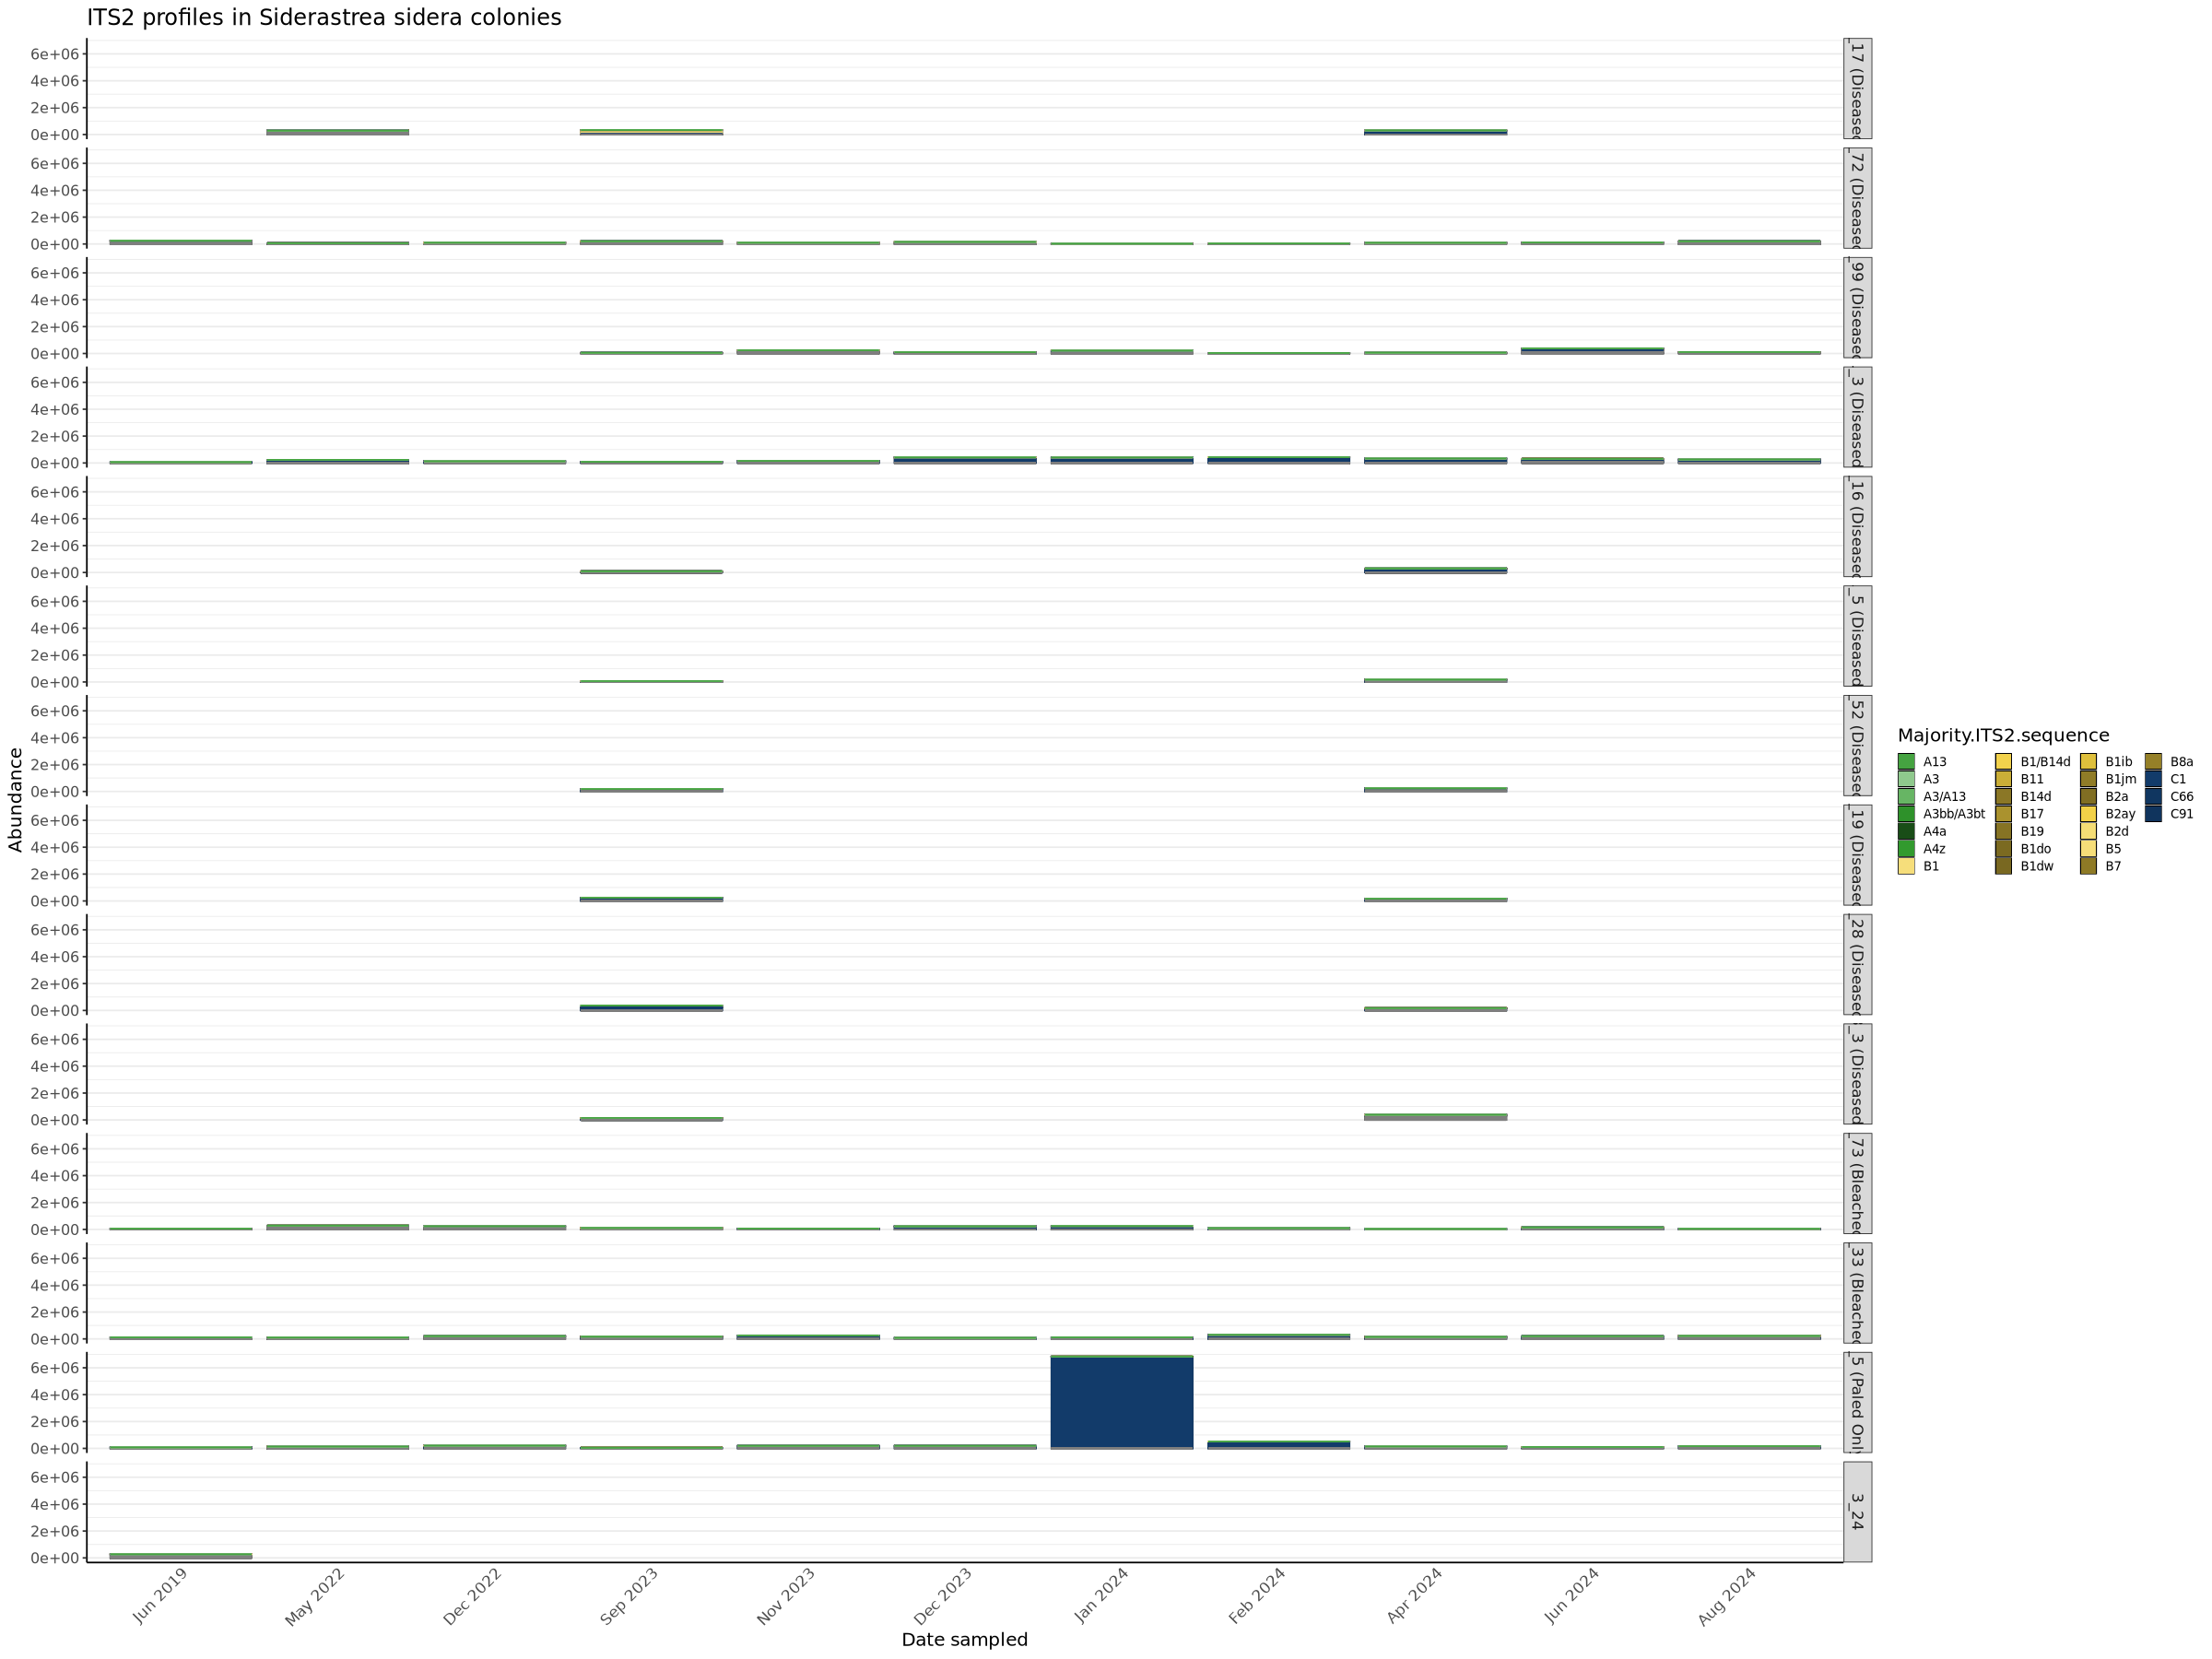

In [113]:

ssid_majority_its2= plot_bar(ps_ssid, x= "Month_year", fill = "Majority.ITS2.sequence") +
facet_wrap(colony_labeled ~., strip.position = "right",  ncol = 1) + # Set desired font size
geom_bar(aes(color = Majority.ITS2.sequence, fill = Majority.ITS2.sequence), 
           stat = "identity", position = "stack") +
  labs(title = "ITS2 profiles in Siderastrea sidera colonies",
       x = "Date sampled",
       y = "Abundance",
       color = "Majority.ITS2.sequence") +
    scale_fill_manual(values = profile_colors, drop = TRUE) +
  scale_color_manual(values = profile_colors, drop = TRUE) +
  theme_bw() +
  theme(
    strip.text = element_text(size = 10), 
    legend.position = "right",
    legend.box = "horizontal",                      # Ensures the legend layout behaves as a block
    legend.title = element_text(size = 12),
    legend.text = element_text(size = 8),           # Slightly reduced to create massive plot breathing room
    legend.key.width = unit(0.4, "cm"),  
    legend.key.height = unit(0.4, "cm"), 
    legend.spacing.x = unit(0.2, "cm"), 
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1, size = 10),
    text = element_text(size = 12)                  # Balanced overall text sizing
  ) +                                               # Added the critical missing plus sign
  guides(
    fill = guide_legend(ncol = 4, override.aes = list(size = 4)), # Wraps into 4 columns to keep it compact on the right
    color = "none"                                  # Shuts off the duplicate color legend outline
  ) 
ssid_majority_its2